In [299]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.gridspec as gridspec
import glob 
import seaborn as sns

import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')

from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle
from pipeline.batch_process_oa import plot_oa

from obstacle_avoidance_processing import AvoidanceProcessing

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [240]:
meta_data =r'D:\obstacle_avoidance\metadata\J701\oa_J701.json'
task_name = 'oa'
session = AvoidanceProcessing(meta_data, task=task_name)
session.process()


KeyboardInterrupt: 

In [270]:
meta_data = r"D:\obstacle_avoidance\metadata\J701_704\test_batch_J701_oa.json"
task_name = 'oa'
session = AvoidanceProcessing(meta_data, task=task_name)
session.process()


0it [00:00, ?it/s]

67
df made
pxl
odd_even
trial_start
smooth_ts
dist
ob_cen
start
distance
6
cluster
corner
port
heading
deveation
lateral_error
tortuosity
head_angle_velocity
saving061324_J701LT_control_Rig2_oaraw
saving061324_J701LT_control_Rig2_oa processed


2it [00:17,  8.84s/it]

59
df made
pxl
odd_even
trial_start
smooth_ts
dist
ob_cen
start
distance
6
cluster
corner
port
heading
deveation
lateral_error
tortuosity
head_angle_velocity
saving051923_G8CK1RT_control_Rig2_oaraw
saving051923_G8CK1RT_control_Rig2_oa processed


3it [00:30, 10.32s/it]


In [6]:
df = pd.read_hdf(r"D:\obstacle_avoidance\recordings\062024\J701NN\oa\processed_J701NN_062024_oa.h5"
                 )

In [23]:
list_columns(df,['arena'])

array(['arenaTL_x', 'arenaTL_y', 'arenaTR_x', 'arenaTR_y', 'arenaBL_x',
       'arenaBL_y', 'arenaBR_x', 'arenaBR_y', 'arenaTLouter_x',
       'arenaTLouter_y', 'arenaTRouter_x', 'arenaTRouter_y',
       'arenaBLouter_x', 'arenaBLouter_y', 'arenaBRouter_x',
       'arenaBRouter_y', 'arenaTL_x_cm', 'arenaTL_y_cm', 'arenaTR_x_cm',
       'arenaTR_y_cm', 'arenaBL_x_cm', 'arenaBL_y_cm', 'arenaBR_x_cm',
       'arenaBR_y_cm', 'arenaTLouter_x_cm', 'arenaTLouter_y_cm',
       'arenaTRouter_x_cm', 'arenaTRouter_y_cm', 'arenaBLouter_x_cm',
       'arenaBLouter_y_cm', 'arenaBRouter_x_cm', 'arenaBRouter_y_cm'],
      dtype='<U17')

In [31]:
arena_x = df[['arenaTL_x_cm',
'arenaTR_x_cm','arenaTR_x_cm',
'arenaTL_x_cm',
'arenaTL_x_cm']].median().values.ravel('K')
arena_y = df[['arenaTL_y_cm',
'arenaTL_y_cm','arenaBL_y_cm',
'arenaBL_y_cm',
'arenaTL_y_cm']].median().values.ravel('K')

arena_x_outer = df[['arenaTLouter_x_cm',
'arenaTRouter_x_cm','arenaTRouter_x_cm',
'arenaTLouter_x_cm',
'arenaTLouter_x_cm']].median().values.ravel('K')
arena_y_outer = df[['arenaTLouter_y_cm',
'arenaTLouter_y_cm','arenaBRouter_y_cm',
'arenaBRouter_y_cm',
'arenaTLouter_y_cm']].median().values.ravel('K')

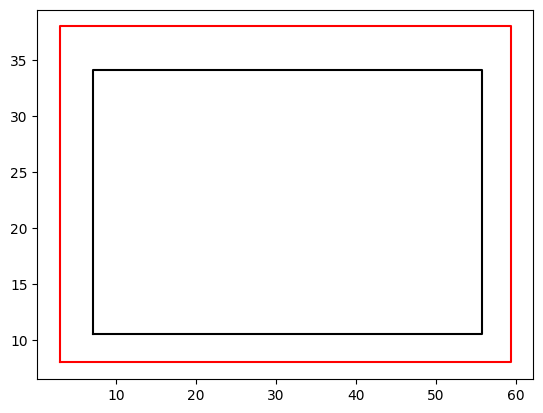

In [32]:
plt.plot([arena_x[0],arena_x[1],arena_x[2],arena_x[3],arena_x[0]],
                          [arena_y[0],arena_y[1],arena_y[2],arena_y[3],arena_y[0]],c='k')

plt.plot([arena_x_outer[0],arena_x_outer[1],arena_x_outer[2],arena_x_outer[3],arena_x_outer[0]],
                          [arena_y_outer[0],arena_y_outer[1],arena_y_outer[2],arena_y_outer[3],arena_y_outer[0]],c='r')

In [245]:
oa_df

,index,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,mean_gt_obstacleBL_x,mean_gt_obstacleBL_y,mean_gt_obstacleTL_x_cm,mean_gt_obstacleTL_y_cm,mean_gt_obstacleTR_x_cm,mean_gt_obstacleTR_y_cm,mean_gt_obstacleBR_x_cm,mean_gt_obstacleBR_y_cm,mean_gt_obstacleBL_x_cm,mean_gt_obstacleBL_y_cm
0,0,57740.743667,57744.602483,"[57740.756659, 57740.773529, 57740.79022, 5774...","[71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 8...","[252.20538330078125, 244.35317993164062, 234.0...","[178.47779846191406, 179.96470642089844, 180.1...","[271.9322814941406, 263.9012145996094, 254.689...","[190.27053833007812, 193.84446716308594, 191.7...","[273.5398254394531, 264.71844482421875, 256.53...",...,253.809902,438.069403,22.168365,21.034906,28.690717,20.913725,28.303068,36.489477,21.624421,37.330289
1,2,57750.091648,57753.008153,"[57750.093427, 57750.110796, 57750.126796, 577...","[631, 632, 633, 634, 635, 636, 637, 638, 639, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[103.25912475585938, 102.69940948486328, 102.5...","[250.8414764404297, 251.43661499023438, 251.44...","[98.15855407714844, 97.75483703613281, 97.5749...",...,253.809902,438.069403,22.168365,21.034906,28.690717,20.913725,28.303068,36.489477,21.624421,37.330289
2,3,57753.008153,57757.153625,"[57753.011148, 57753.028467, 57753.044582, 577...","[[806, 807, 808, 809, 810, 811, 812, 813, 814,...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[667.4151611328125, 668.2945556640625, 668.699...","[242.25291442871094, 242.41732788085938, 242.5...","[663.8762817382812, 664.5556030273438, 664.955...",...,253.809902,438.069403,22.168365,21.034906,28.690717,20.913725,28.303068,36.489477,21.624421,37.330289
3,5,57763.396492,57766.636620,"[57763.397926, 57763.415308, 57763.43136, 5776...","[[1429, 1430, 1431, 1432, 1433, 1434, 1435, 14...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[668.6185913085938, 669.13720703125, 670.06170...","[238.8343048095703, 239.07716369628906, 238.94...","[663.9497680664062, 664.3980102539062, 665.014...",...,253.809902,438.069403,22.168365,21.034906,28.690717,20.913725,28.303068,36.489477,21.624421,37.330289
4,6,57766.636620,57770.491264,"[57766.649868, 57766.665715, 57766.682892, 577...","[1624, 1625, 1626, 1627, 1628, 1629, 1630, 163...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[101.1065673828125, 101.013671875, 101.5311355...","[252.25733947753906, 252.11746215820312, 252.4...","[97.01448822021484, 96.82373046875, 97.4176254...",...,397.649223,354.277488,33.917722,14.419720,40.080059,14.434891,40.433546,29.533444,33.859893,30.168652
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
337,108,59609.957414,59613.041971,"[59609.958515, 59609.975744, 59609.992537, 596...","[33479, 33480, 33481, 33482, 33483, 33484, 334...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[93.86324310302734, 94.03146362304688, 94.3227...","[261.73687744140625, 260.33734130859375, 260.1...","[102.77198791503906, 102.96442413330078, 103.0...",...,397.649223,354.277488,33.917722,14.419720,40.080059,14.434891,40.433546,29.533444,33.859893,30.168652
338,109,59613.041971,59616.634406,"[59613.042969, 59613.060057, 59613.076864, 596...","[[33664, 33665, 33666, 33667, 33668, 33669, 33...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[661.5934448242188, 662.3602294921875, 662.542...","[248.394775390625, 247.96888732910156, 248.547...","[669.5333251953125, 669.127197265625, 669.2597...",...,397.649223,354.277488,33.917722,14.419720,40.080059,14.434891,40.433546,29.533444,33.859893,30.168652
339,110,59616.634406,59619.280601,"[59616.644569, 59616.66

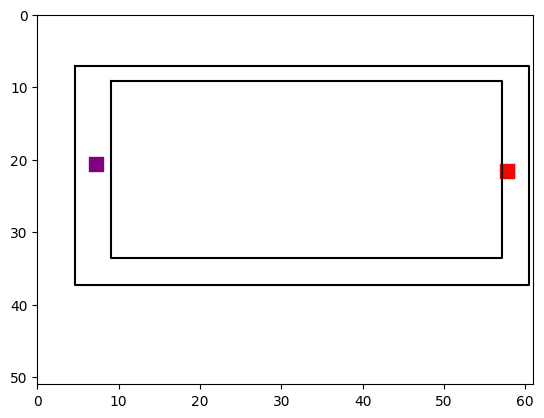

In [243]:
fig,ax = plt.subplots()
plot_arena(oa_df,ax)

In [249]:
J701_df.obstacle_ind

0       159.0
1       205.0
2       127.0
3       199.0
4        30.0
        ...  
5265     25.0
5266     71.0
5268     36.0
5269     19.0
5270    143.0
Name: obstacle_ind, Length: 4201, dtype: float64

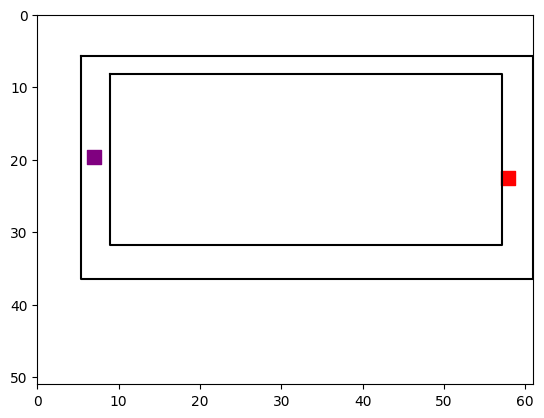

In [242]:
fig,ax = plt.subplots()
plot_arena(J701_df,ax)

In [239]:
cal

,level_0,index,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,...,distance_from_mean_center,ts_lateral_error_to_target_port,ob_tortuosity_10,ob_linearity_10,percent_change_ob_tortuosity_10,percent_change_ob_linearity_10,ts_angle_to_obstacle,ts_leye_angle_to_obstacle,ts_reye_angle_to_obstacle,ts_body_angle_to_obstacle
2736,20,20.0,56127.891904,56130.022092,"[56127.905792, 56127.92142, 56127.939366, 5612...","[2769, 2770, 2771, 2772, 2773, 2774, 2775, 277...","[110.34358215332031, nan, nan, nan, nan, nan, ...","[274.4992980957031, nan, nan, nan, nan, nan, n...","[121.3622055053711, 120.42849731445312, 119.33...","[273.53790283203125, 273.34259033203125, 273.3...",...,2.573770,"[3.5310272200469868, 3.6245881216425957, 3.462...",1.037797,0.963579,-0.866729,0.798079,"[40.655179360584405, 35.64134157676367, 24.689...","[103.06167890953695, nan, nan, nan, nan, nan, ...","[123.93266874330808, nan, nan, nan, nan, nan, ...","[95.46958293648139, 85.23005729991988, 78.7805..."
2743,28,28.0,56145.977369,56148.042048,"[56145.977651, 56145.99447, 56146.01134, 56146...","[3853, 3854, 3855, 3856, 3857, 3858, 3859, 386...","[110.8899917602539, 110.91999053955078, 111.47...","[277.0853271484375, 276.6024169921875, 276.000...","[125.79975891113281, 124.6924057006836, 123.38...","[274.59716796875, 273.8061828613281, 273.25628...",...,2.930044,"[4.047696405417749, 4.26563451219053, 4.435242...",1.047094,0.955025,-7.510244,6.391457,"[32.69787769396559, 30.113599489800723, 27.997...","[98.84290280590778, 99.74641364789622, 106.014...","[136.61641000239163, 134.2061083414141, 127.15...","[92.96902936098908, 84.4104301075644, 73.33586..."
2784,69,70.0,56240.488358,56242.212851,"[56240.494105, 56240.510617, 56240.528051, 562...","[9522, 9523, 9524, 9525, 9526, 9527, 9528, 952...","[nan, nan, nan, nan, nan, nan, nan, 111.086692...","[nan, nan, nan, nan, nan, nan, nan, 275.452362...","[121.9453353881836, 120.66397857666016, 120.23...","[273.02069091796875, 272.6563415527344, 273.44...",...,2.690034,"[3.3622865409215557, 3.4328792049411803, 3.436...",1.032109,0.968890,-2.976818,2.716142,"[44.16073618854607, 39.58385725358457, 30.9092...","[nan, nan, nan, nan, nan, nan, nan, 103.731692...","[nan, nan, nan, nan, nan, nan, nan, 125.693909...","[99.44880069838666, 88.38511984373842, 79.5206..."
2790,75,76.0,56253.973555,56255.890636,"[56253.98208, 56253.998464, 56254.015321, 5625...","[10331, 10332, 10333, 10334, 10335, 10336, 103...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[119.072021484375, 121.48161315917969, 121.609...","[274.7441711425781, 273.65863037109375, 273.37...",...,1.339294,"[2.359682193698628, 2.346068473281001, 2.04747...",1.021852,0.978615,-0.366180,0.349433,"[38.111108349241476, 34.25803214769243, 24.766...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[92.60088218389123, 89.21365775403225, 81.4170..."
2815,103,108.0,56338.522099,56340.443238,"[56338.527616, 56338.544691, 56338.560921, 563...","[15402, 15403, 15404, 15405, 15406, 15407, 154...","[111.0956802368164, 111.24260711669922, 111.41...","[277.17364501953125, 276.3160705566406, 275.94...","[127.78819274902344, 126.67974853515625, 126.6...","[274.0004577636719, 272.8050537109375, 272.417...",...,0.434315,"[4.9243953162940635, 5.0355859313804565, 5.022...",NaN,NaN,NaN,NaN,"[59.650727411028505, 53.739838360141526, 43.76...","[108.20399030301813, 106.75382789953444, 105.2...","[135.6262353233783, 135.57086294870305, 136.06...","[95.4585689095091, 86.6589250266625, 84.121180..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8728,88,91.0,44689.468697,44691.795187,"[44689.470092, 44689.486963, 44689.504332, 446...","[[15720, 15721, 15722, 15723, 15724, 15725, 15...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[679.75341796875

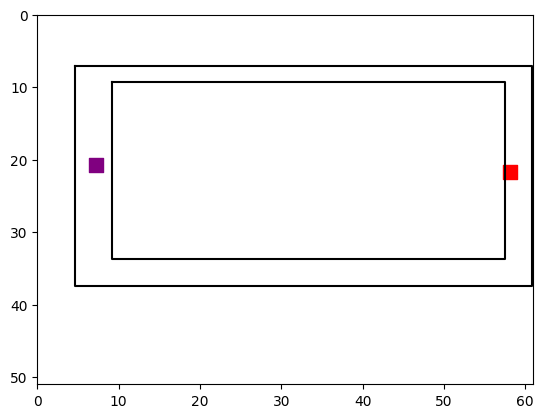

In [7]:
fig,ax = plt.subplots()
plot_arena(df,ax)

In [10]:
def by_start_obstalce_average(df,title,samples,dark =False):
        key='Start'
        fig = plt.figure(constrained_layout=False, figsize=(16, 10),dpi=90)
        fig.suptitle(key + ' '+ 'and ' +'obstacle position' + ' ' + title)
        spec2 = gridspec.GridSpec(ncols=2, nrows=1, figure=fig)


        """Right"""
        panel_1 = gridspec.GridSpecFromSubplotSpec(3,2,subplot_spec=spec2[0])
        ax1 = fig.add_subplot(panel_1[0,0])
        plot_arena(df,ax1)
        ax2 = fig.add_subplot(panel_1[0,1])
        plot_arena(df,ax2)
        ax2.set_title('right')
        ax3 = fig.add_subplot(panel_1[1,0])
        plot_arena(df,ax3)
        ax4 = fig.add_subplot(panel_1[1,1])
        plot_arena(df,ax4)
        ax5 = fig.add_subplot(panel_1[2,0])
        plot_arena(df,ax5)
        ax6 = fig.add_subplot(panel_1[2,1])
        plot_arena(df,ax6)

        right_axs = [ax1,ax2,ax3,ax4,ax5,ax6]
        for subplot in right_axs:
          subplot.set_xticks([])
          subplot.set_yticks([]) 
          if dark == True:
               subplot.set_facecolor('grey') 
               subplot.patch.set_alpha(.4) 
          else:
               continue
               


        """Left """
        panel_2 = gridspec.GridSpecFromSubplotSpec(3,2,subplot_spec=spec2[1])
        ax7 = fig.add_subplot(panel_2[0,0])
        plot_arena(df,ax7)
        ax8 = fig.add_subplot(panel_2[0,1])
        plot_arena(df,ax8)
        ax8.set_title('left')
        ax9 = fig.add_subplot(panel_2[1,0])
        plot_arena(df,ax9)
        ax10 = fig.add_subplot(panel_2[1,1])
        plot_arena(df,ax10)
        ax11= fig.add_subplot(panel_2[2,0])
        plot_arena(df,ax11)
        ax12 = fig.add_subplot(panel_2[2,1])
        plot_arena(df,ax12)

        left_axs = [ax7,ax8,ax9,ax10,ax11,ax12]
        for subplot in left_axs:
          subplot.set_xticks([])
          subplot.set_yticks([]) 
          if dark == True:
               subplot.set_facecolor('grey') 
               subplot.patch.set_alpha(.4) 
          else:
               continue
               






        """ plot trials"""
        right_obstacle_dict = dict(zip(pd.unique(df['obstacle_cluster'].sort_values().to_list()),right_axs))
        left_obstacle_dict = dict(zip(pd.unique(df['obstacle_cluster'].sort_values().to_list()),left_axs))

        for direction, direction_frame in df.groupby(['odd']):
            for cluster, cluster_frame in direction_frame.groupby(['obstacle_cluster']):
                #cluster_frame = cluster_frame.sample(num_sample)
                right_obstacle_axis = right_obstacle_dict.get(cluster)
                left_obstacle_axis = left_obstacle_dict.get(cluster)
                if direction =='right':
                    plot_orginal_obstacle(cluster_frame,right_obstacle_axis,cluster=cluster)
                else:
                    plot_orginal_obstacle(cluster_frame,left_obstacle_axis,cluster=cluster)
                right_obstacle_axis.set_title(str(cluster))
                left_obstacle_axis.set_title(str(cluster))
                for start, start_frame in cluster_frame.groupby(['start']):
                     if direction == 'right':
                         if start == 'bottom':
                              if cluster in [2,3]:
                                   sample_df = start_frame
                                   for ind,row in sample_df.iterrows():
                                        right_obstacle_axis.plot(row.ts_nose_x_cm,row.ts_nose_y_cm,c = 'tab:orange',alpha = .3)
                                   #3ob_median_x = get_median_of_df(start_frame,'ts_nose_x_cm',50) 
                                   #ob_median_y = get_median_of_df(start_frame,'ts_nose_y_cm',50)
                                   #right_obstacle_axis.plot(ob_median_x,ob_median_y,color = 'black')
                                   
                                   
                                                                                                                    
                              else:     
                                   sample_df = start_frame
                                   for ind,row in sample_df.iterrows():
                                        right_obstacle_axis.plot(row.ts_nose_x_cm,row.ts_nose_y_cm,c = 'tab:orange',alpha = .3)
                                   #ob_mean_x = get_mean_of_df(start_frame,'ts_nose_x_cm',50) 
                                   #ob_mean_y = get_mean_of_df(start_frame,'ts_nose_y_cm',50)
                                   #right_obstacle_axis.plot(ob_mean_x,ob_mean_y,color = 'black')
                                   
                     
                         if start == 'top':
                              if cluster in [2,3]:
                                   sample_df = start_frame
                                   for ind,row in sample_df.iterrows():
                                        right_obstacle_axis.plot(row.ts_nose_x_cm,row.ts_nose_y_cm,c = 'tab:blue',alpha =.3)
                                   #ob_median_x = get_median_of_df(start_frame,'ts_nose_x_cm',50) 
                                   #ob_median_y = get_median_of_df(start_frame,'ts_nose_y_cm',50)
                                   #right_obstacle_axis.plot(ob_median_x,ob_median_y,color = 'tab:red')
                                   
                                   
                              else:
                                   sample_df = start_frame 
                                   for ind,row in sample_df.iterrows():
                                        right_obstacle_axis.plot(row.ts_nose_x_cm,row.ts_nose_y_cm,c = 'tab:blue',alpha =.3)    
                                   #ob_mean_x = get_mean_of_df(start_frame,'ts_nose_x_cm',50) 
                                   #ob_mean_y = get_mean_of_df(start_frame,'ts_nose_y_cm',50)
                                   #right_obstacle_axis.plot(ob_mean_x,ob_mean_y,color = 'tab:red')
                                   
                                   
           
                               
                     if direction == 'left':
                         if start == 'bottom':
                              if cluster in [2,3]:
                                   sample_df = start_frame
                                   for ind,row in sample_df.iterrows():
                                        left_obstacle_axis.plot(row.ts_nose_x_cm,row.ts_nose_y_cm,c = 'tab:orange',alpha = .3)
                                   ob_median_x = get_median_of_df(start_frame,'ts_nose_x_cm',50) 
                                   ob_median_y = get_median_of_df(start_frame,'ts_nose_y_cm',50)
                                   #left_obstacle_axis.plot(ob_median_x,ob_median_y,color = 'black')
                                   
                                   
                                                                                                                    
                              else:     
                                   sample_df = start_frame
                                   for ind,row in sample_df.iterrows():
                                        left_obstacle_axis.plot(row.ts_nose_x_cm,row.ts_nose_y_cm,c = 'tab:orange',alpha = .3)
                                   ob_mean_x = get_mean_of_df(start_frame,'ts_nose_x_cm',50) 
                                   ob_mean_y = get_mean_of_df(start_frame,'ts_nose_y_cm',50)
                                   #left_obstacle_axis.plot(ob_mean_x,ob_mean_y,color = 'black')
                                   
                         
                         if start == 'top':
                              if cluster in [2,3]:
                                   sample_df = start_frame
                                   for ind,row in sample_df.iterrows():
                                        left_obstacle_axis.plot(row.ts_nose_x_cm,row.ts_nose_y_cm,c = 'tab:blue',alpha =.3)
                                   ob_median_x = get_median_of_df(start_frame,'ts_nose_x_cm',50) 
                                   ob_median_y = get_median_of_df(start_frame,'ts_nose_y_cm',50)
                                   #left_obstacle_axis.plot(ob_median_x,ob_median_y,color = 'tab:red')
                                   
                                   
                              else:
                                   sample_df = start_frame 
                                   for ind,row in sample_df.iterrows():
                                        left_obstacle_axis.plot(row.ts_nose_x_cm,row.ts_nose_y_cm,c = 'tab:blue',alpha =.3)    
                                   ob_mean_x = get_mean_of_df(start_frame,'ts_nose_x_cm',50) 
                                   ob_mean_y = get_mean_of_df(start_frame,'ts_nose_y_cm',50)
                                   #left_obstacle_axis.plot(ob_mean_x,ob_mean_y,color = 'tab:red')
        markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='') for color in ['tab:orange','tab:blue']]
        ax1.legend(markers, ['bottom','top'], numpoints=1,title = 'Trajectory',fontsize=13)

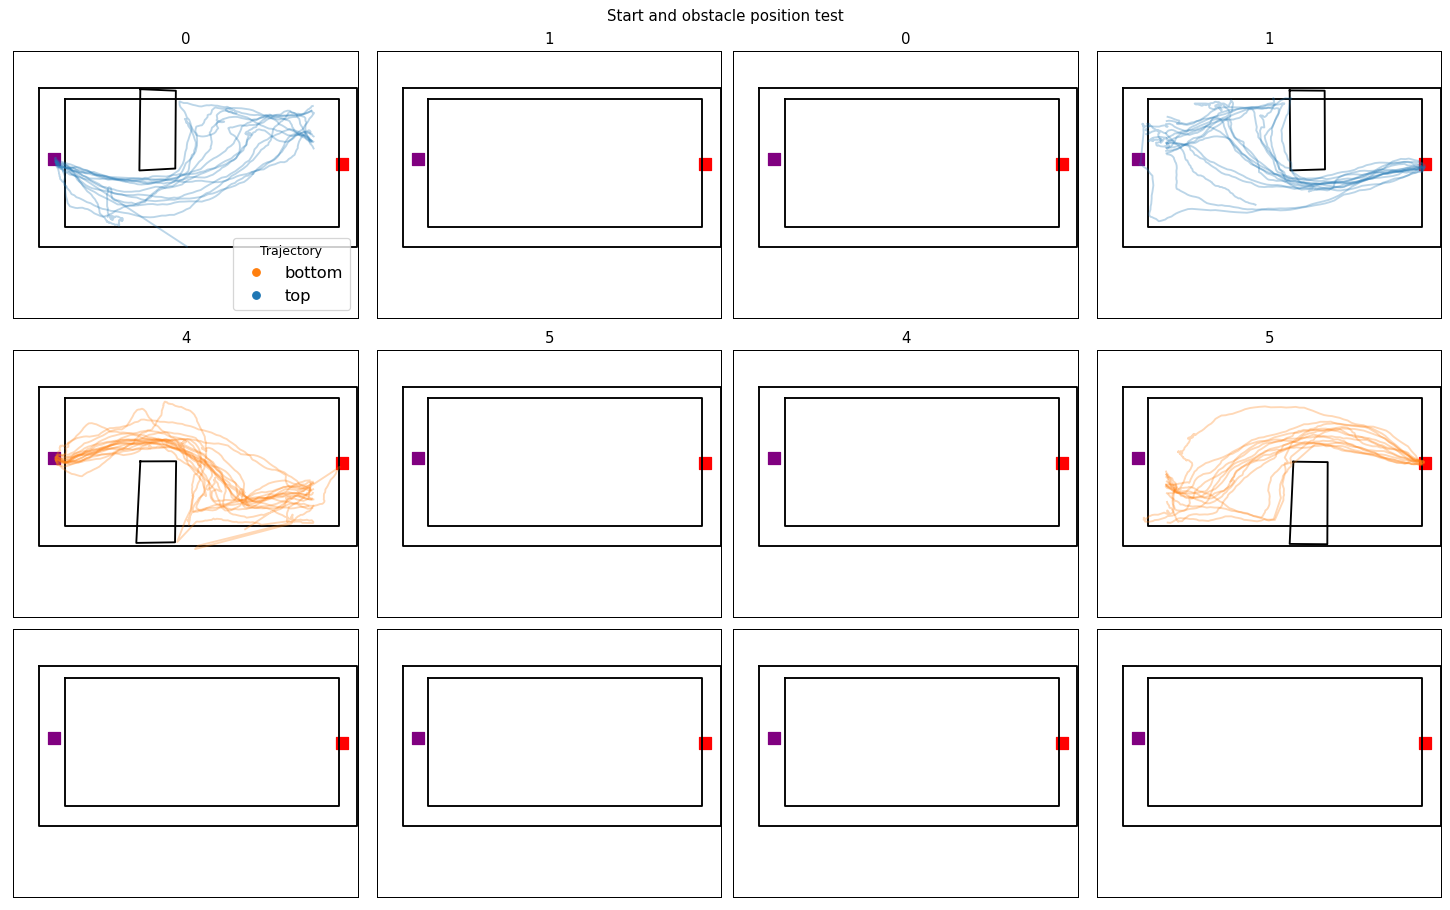

In [61]:
by_start_obstalce_average(long,'test',samples=1)

In [13]:
oa_session = plot_oa(r"D:\obstacle_avoidance\metadata\J701_704\test_J701_062024_oa.json",'blank')
oa_session.gather_session_df('obstacle',6)
oa_df = oa_session.df

6


In [22]:
short

,index,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,mean_gt_obstacleBL_x,mean_gt_obstacleBL_y,mean_gt_obstacleTL_x_cm,mean_gt_obstacleTL_y_cm,mean_gt_obstacleTR_x_cm,mean_gt_obstacleTR_y_cm,mean_gt_obstacleBR_x_cm,mean_gt_obstacleBR_y_cm,mean_gt_obstacleBL_x_cm,mean_gt_obstacleBL_y_cm
14,20,57818.520806,57821.650688,"[57818.533913, 57818.551052, 57818.567168, 578...","[4736, 4737, 4738, 4739, 4740, 4741, 4742, 474...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[94.55078887939453, 93.87076568603516, 93.7912...","[262.0126953125, 261.6270751953125, 261.458282...","[102.31002807617188, 102.19293212890625, 101.9...",...,262.886161,270.275804,22.280119,7.544378,28.685385,7.838951,28.716983,22.716295,22.415411,23.044251
36,44,57892.349299,57895.888499,"[57892.359321, 57892.376, 57892.392665, 57892....","[9164, 9165, 9166, 9167, 9168, 9169, 9170, 917...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[94.60307312011719, 94.28033447265625, 94.3058...","[260.2176208496094, 259.863037109375, 260.0818...","[102.91600799560547, 102.72526550292969, 102.6...",...,262.886161,270.275804,22.280119,7.544378,28.685385,7.838951,28.716983,22.716295,22.415411,23.044251
54,66,57958.767462,57962.454003,"[57958.783193, 57958.79872, 57958.815552, 5795...","[13148, 13149, 13150, 13151, 13152, 13153, 131...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[95.64075469970703, 95.34902954101562, 95.7321...","[257.2241516113281, 256.9004211425781, 256.648...","[103.81965637207031, 103.1949691772461, 103.36...",...,262.886161,270.275804,22.280119,7.544378,28.685385,7.838951,28.716983,22.716295,22.415411,23.044251
87,108,58123.637004,58127.245683,"[58123.63886, 58123.655795, 58123.672499, 5812...","[23036, 23037, 23038, 23039, 23040, 23041, 230...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[96.00484466552734, 95.89833068847656, 95.6236...","[257.5513610839844, 257.2073974609375, 257.216...","[104.25401306152344, 103.19297790527344, 102.9...",...,262.886161,270.275804,22.280119,7.544378,28.685385,7.838951,28.716983,22.716295,22.415411,23.044251
104,134,58316.521472,58320.040051,"[58316.522828, 58316.538892, 58316.5563, 58316...","[34605, 34606, 34607, 34608, 34609, 34610, 346...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[95.4159927368164, 95.01506042480469, 94.75340...","[258.90155029296875, 259.77313232421875, 259.7...","[103.33195495605469, 103.12726593017578, 102.7...",...,262.886161,270.275804,22.280119,7.544378,28.685385,7.838951,28.716983,22.716295,22.415411,23.044251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,9,59096.681625,59105.148851,"[59096.683392, 59096.698278, 59096.714918, 590...","[[2693, 2694, 2695, 2696, 2697, 2698, 2699, 27...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[667.9552612304688, 668.2451782226562, 668.713...","[239.22181701660156, 239.499755859375, 239.361...","[662.1870727539062, 662.64990234375, 663.38635...",...,401.958578,432.090656,34.879399,21.264222,40.902398,21.378152,40.859252,37.034153,34.226144,36.792283
260,11,59108.704486,59114.668838,"[59108.719974, 59108.735692, 59108.752422, 591...","[[3415, 3416, 3417, 3418, 3419, 3420, 3421, 34...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[668.7312622070312, 668.9217529296875, 669.387...","[241.6240234375, 241.91004943847656, 242.09498...","[663.6221923828125, 663.7954711914062, 664.611...",...,401.958578,432.090656,34.879399,21.264222,40.902398,21.378152,40.859252,37.034153,34.226144,36.792283
285,37,59205.435584,59209.454579,"[59205.435788, 59205.452

In [157]:
long,short,middle = create_df_by_type(oa_df)

In [215]:
light = pd.read_hdf(r"D:\obstacle_avoidance\recordings\data_h5\oa_df_051024.h5")

In [290]:
dark = pd.read_hdf(r"D:\obstacle_avoidance\recordings\data_h5\dark_oa_df_051024.h5")

In [216]:
long,short,middle = create_df_by_type(light)

In [291]:
dark_long,dark_lshort,dark_lmiddle = create_df_by_type(dark)

In [250]:

J701_long,J701_short,J701_middle = create_df_by_type(J701_df)

In [155]:
long

,level_0,index,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,...,distance_from_mean_center,ts_lateral_error_to_target_port,ob_tortuosity_10,ob_linearity_10,percent_change_ob_tortuosity_10,percent_change_ob_linearity_10,ts_angle_to_obstacle,ts_leye_angle_to_obstacle,ts_reye_angle_to_obstacle,ts_body_angle_to_obstacle
18,19,23.0,55968.446784,55972.150118,"[55968.457036, 55968.474214, 55968.490777, 559...","[[7724, 7725, 7726, 7727, 7728, 7729, 7730, 77...","[684.8956909179688, 685.5166625976562, 686.734...","[276.1261901855469, 276.2704162597656, 276.096...","[669.5835571289062, 670.5010375976562, 671.231...","[272.48040771484375, 271.9192810058594, 271.15...",...,0.997439,"[7.053168420527934, 7.313772759461646, 7.51374...",1.166560,0.857221,-48.186364,25.058111,"[46.041449414567765, 45.13298398198541, 40.190...","[79.49850009460586, 79.71951278093063, 80.8605...","[155.02696200153045, 153.64240110253633, 153.9...","[59.73932045430363, 54.68336892298184, 54.5761..."
29,30,35.0,56025.418905,56030.842496,"[56025.427046, 56025.443699, 56025.460428, 560...","[[11141, 11142, 11143, 11144, 11145, 11146, 11...","[681.3780517578125, nan, nan, nan, nan, nan, n...","[275.2206115722656, nan, nan, nan, nan, nan, n...","[669.8692626953125, 671.6943969726562, 674.338...","[268.4548034667969, 268.9363708496094, 268.745...",...,1.033280,"[5.418002339556118, 5.666461405809718, 5.77270...",1.008053,0.992011,-64.792768,38.813956,"[39.65396513253671, 39.5243883357124, 34.58114...","[99.07211770246643, nan, nan, nan, nan, nan, n...","[123.74314091538957, nan, nan, nan, nan, nan, ...","[34.66239953401311, 28.667113271992374, 12.804..."
40,41,47.0,56089.383270,56096.416729,"[56089.399347, 56089.415577, 56089.432332, 560...","[[14978, 14979, 14980, 14981, 14982, 14983, 14...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[675.2911376953125, 677.028076171875, 678.3170...","[264.6787414550781, 265.697021484375, 266.2087...",...,0.496675,"[0.6689760986460023, 0.6631478828115931, 0.663...",1.032358,0.968656,-79.217029,42.056934,"[56.63099739514353, 54.329858805383545, 54.501...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[92.21798346859427, 91.81566447472747, 86.7136..."
42,43,49.0,56101.012761,56104.130214,"[56101.019648, 56101.036364, 56101.053452, 561...","[[15675, 15676, 15677, 15678, 15679, 15680, 15...","[686.4649658203125, 685.9793090820312, nan, na...","[275.90142822265625, 277.9461975097656, nan, n...","[670.5230712890625, 671.7032470703125, 672.822...","[271.092041015625, 270.7273864746094, 270.5169...",...,0.474120,"[6.982522017137882, 7.137387559696453, 7.30714...",1.086644,0.920264,1.050195,-0.898076,"[50.882120564437905, 49.12850549583193, 47.520...","[81.01684911838667, 77.02622603937118, nan, na...","[152.65410279415025, 147.96504321007137, nan, ...","[66.41071311187497, 65.5955327279069, 60.33092..."
55,56,63.0,56172.563955,56176.160588,"[56172.578176, 56172.594867, 56172.612428, 561...","[[19967, 19968, 19969, 19970, 19971, 19972, 19...","[683.0909423828125, 684.2697143554688, 686.127...","[274.2113342285156, 273.2940673828125, 273.591...","[667.3619384765625, 669.4915771484375, 673.093...","[271.208740234375, 271.1734924316406, 270.4080...",...,0.487887,"[7.168966925752924, 7.251540813091665, 7.29835...",1.618867,0.617716,6.654267,-2.647932,"[45.736882399125136, 43.34907357252363, 40.856...","[76.59761956739958, 77.81757299387692, 80.0005...","[155.60044970028687, 156.09092975674585, 151.2...","[67.91731230556252, 60.23662578541259, 56.2619..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13307,114,128.0,47530.865241,47533.400883,"[47530.877222, 47530.894003, 47530.911603, 475...","[18763, 18764, 18765, 18766, 18767, 18768, 187...","[79.05038452148438, 78.36024475097656, 77.8957...","[252.8020477294922, 252.91268920898438, 252.87..."

In [222]:
long.skill

18       naive
29       naive
40       naive
42       naive
55       naive
         ...  
13307     late
13310     late
13324     late
13363     late
13384     late
Name: skill, Length: 2751, dtype: object

In [223]:
long[long.skill==  'early']

,level_0,index,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,...,distance_from_mean_center,ts_lateral_error_to_target_port,ob_tortuosity_10,ob_linearity_10,percent_change_ob_tortuosity_10,percent_change_ob_linearity_10,ts_angle_to_obstacle,ts_leye_angle_to_obstacle,ts_reye_angle_to_obstacle,ts_body_angle_to_obstacle
1265,10,11.0,56266.063257,56269.348518,"[56266.071001, 56266.087449, 56266.103948, 562...","[[2064, 2065, 2066, 2067, 2068, 2069, 2070, 20...","[686.943115234375, 686.9986572265625, 687.8292...","[276.6282958984375, 275.50244140625, 275.31033...","[670.921142578125, 670.1024169921875, 672.1974...","[268.39202880859375, 269.1513366699219, 268.52...",...,0.955291,"[2.201696531062172, 2.165878243993344, 1.25503...",1.001129,0.998873,-90.572025,47.444720,"[53.92115307018026, 53.32850475066364, 75.5762...","[90.51055664929233, 86.89340599186411, 88.9749...","[134.1733220073198, 141.60243721221775, 137.99...","[73.95729026754107, 72.90283389472597, 74.6282..."
1267,12,13.0,56271.646528,56274.362368,"[56271.655628, 56271.672499, 56271.690112, 562...","[[2399, 2400, 2401, 2402, 2403, 2404, 2405, 24...","[684.8056030273438, 685.8978881835938, nan, na...","[272.0619812011719, 271.8953552246094, nan, na...","[669.5033569335938, 672.3786010742188, 672.655...","[270.0235290527344, 268.62298583984375, 268.13...",...,0.951393,"[2.5134829020199625, 2.855383227519802, 3.0263...",1.615885,0.618856,-6.450056,2.375441,"[48.14982137101456, 47.74213078981713, 43.0920...","[88.02610198679781, 93.09119115569052, nan, na...","[144.87745795273344, 138.5616193677207, nan, n...","[78.01236880956125, 68.21901113564766, 60.6703..."
1274,19,21.0,56296.884096,56300.083302,"[56296.897612, 56296.915724, 56296.93111, 5629...","[[3913, 3914, 3915, 3916, 3917, 3918, 3919, 39...","[685.7388916015625, 686.6453247070312, 687.091...","[275.75408935546875, 275.2820739746094, 275.31...","[669.8013305664062, 670.3114013671875, 670.658...","[271.9601135253906, 271.1204528808594, 270.455...",...,0.805209,"[3.1167840881124604, 3.0596354775698877, 3.091...",1.002875,0.997133,-2.624891,2.543293,"[47.54004924748601, 40.16117243207512, 38.3509...","[90.83570450056162, 91.2758690654409, 91.29484...","[145.61502423866975, 145.87221284744143, 143.2...","[58.7428652752657, 58.17617254002316, 56.80053..."
1280,25,27.0,56312.454310,56315.080204,"[56312.469798, 56312.487475, 56312.503436, 563...","[[4847, 4848, 4849, 4850, 4851, 4852, 4853, 48...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[674.6927490234375, 676.7650146484375, 677.315...","[263.50042724609375, 263.4181213378906, 262.63...",...,0.456490,"[3.6232677746908877, 3.865900647822457, 4.1713...",1.028221,0.972553,-9.187350,7.977173,"[45.75737299988347, 44.27227511297589, 46.5687...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[78.29593572075838, 70.15530932589807, 60.5845..."
1282,27,29.0,56317.935513,56320.266048,"[56317.938227, 56317.955379, 56317.972787, 563...","[[5175, 5176, 5177, 5178, 5179, 5180, 5181, 51...","[686.66015625, 687.8616333007812, nan, nan, na...","[275.6385192871094, 275.2350769042969, nan, na...","[670.8175048828125, 672.1040649414062, 672.713...","[272.3093566894531, 270.1821594238281, 270.108...",...,0.453173,"[4.478459840209975, 4.601340768639439, 4.90506...",1.024800,0.975800,-16.243598,13.350763,"[57.006931789638514, 52.64365030220182, 48.353...","[89.10077381873677, 91.64102915725401, nan, na...","[147.653957961274, 143.4291053221661, nan, nan...","[69.99027413961281, 65.9306371621413, 60.03976..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6866,71,78.0,43357.997875,43360.607385,"[43358.010598, 43358.026304, 43358.043097, 433...","[12837, 12838, 12839, 12840, 12841, 12842, 128...","[108.5783920288086, 108.30767822265625, 107.79...","[272.0180358886719, 271.9075012207031, 271.57

In [220]:
long.date

18       042823
29       042823
40       042823
42       042823
55       042823
          ...  
13307    072823
13310    072823
13324    072823
13363    072823
13384    072823
Name: date, Length: 2751, dtype: object

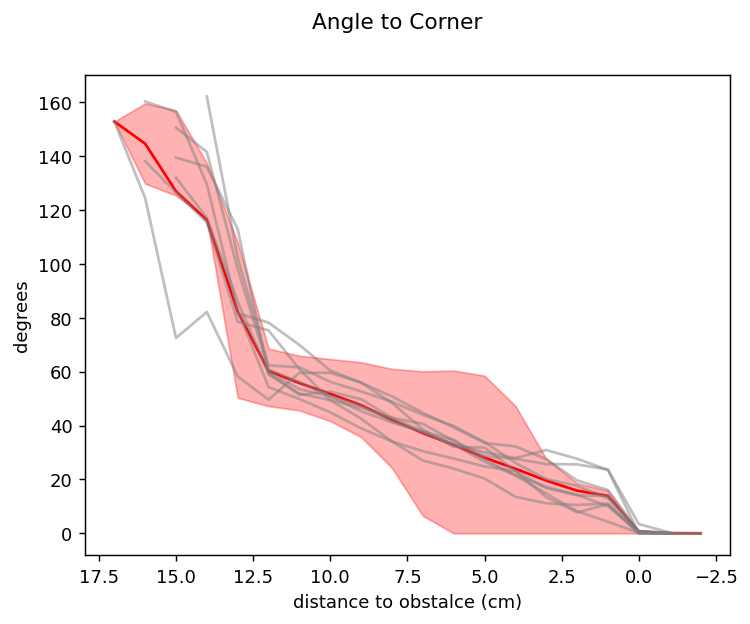

In [237]:
df = short[short.skill==  'middle']
df = drop_nans_in_columns(df,'obstacle_ind')
fig,ax = plt.subplots(dpi = 130)
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
fig.suptitle('Angle to Corner')
#ax.invert_xaxis()
#ax.invert_xaxis()

xnew =  np.arange(-2, 20, 1) 
xnew= np.flip(xnew)

#xnew= np.flip(xnew)

rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmean(angle_array,axis = 0)
ax.invert_xaxis()
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)
ax.fill_between(xnew, q1, q3, color='r', alpha=0.3, label='IQR')

for ani,ani_df in df.groupby(['animal']):
    rows = ani_df.shape[0]
    angle_array = np.empty([rows,xnew.size])
    angle_array[:] =np.nan
    for i,row in enumerate(ani_df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        interpolater = interp1d(x,y,bounds_error=False)
        ynew = interpolater(xnew)
        angle_array[i] = ynew
    angle_mean = np.nanmean(angle_array,axis = 0)
    angle_median= np.nanmedian(angle_array,axis = 0)

    ax.plot(xnew,angle_mean,color = 'grey',alpha = .5)
    median, q1, q3, iqr = calculate_quartiles(angle_array)
    #ax.fill_between(xnew, q1, q3, color='grey', alpha=0.3, label='IQR')

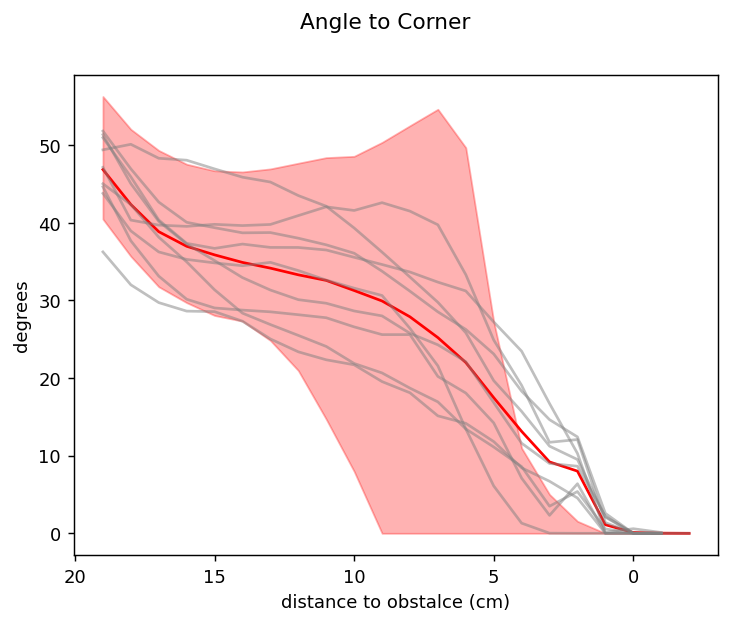

In [230]:
df = long[long.skill==  'late']
df = drop_nans_in_columns(df,'obstacle_ind')
fig,ax = plt.subplots(dpi = 130)
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
fig.suptitle('Angle to Corner')
#ax.invert_xaxis()
#ax.invert_xaxis()

xnew =  np.arange(-2, 20, 1) 
xnew= np.flip(xnew)

#xnew= np.flip(xnew)

rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmean(angle_array,axis = 0)
ax.invert_xaxis()
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)
ax.fill_between(xnew, q1, q3, color='r', alpha=0.3, label='IQR')

for ani,ani_df in df.groupby(['animal']):
    rows = ani_df.shape[0]
    angle_array = np.empty([rows,xnew.size])
    angle_array[:] =np.nan
    for i,row in enumerate(ani_df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        interpolater = interp1d(x,y,bounds_error=False)
        ynew = interpolater(xnew)
        angle_array[i] = ynew
    angle_mean = np.nanmean(angle_array,axis = 0)
    angle_median= np.nanmedian(angle_array,axis = 0)

    ax.plot(xnew,angle_mean,color = 'grey',alpha = .5)
    median, q1, q3, iqr = calculate_quartiles(angle_array)
    #ax.fill_between(xnew, q1, q3, color='grey', alpha=0.3, label='IQR')
    

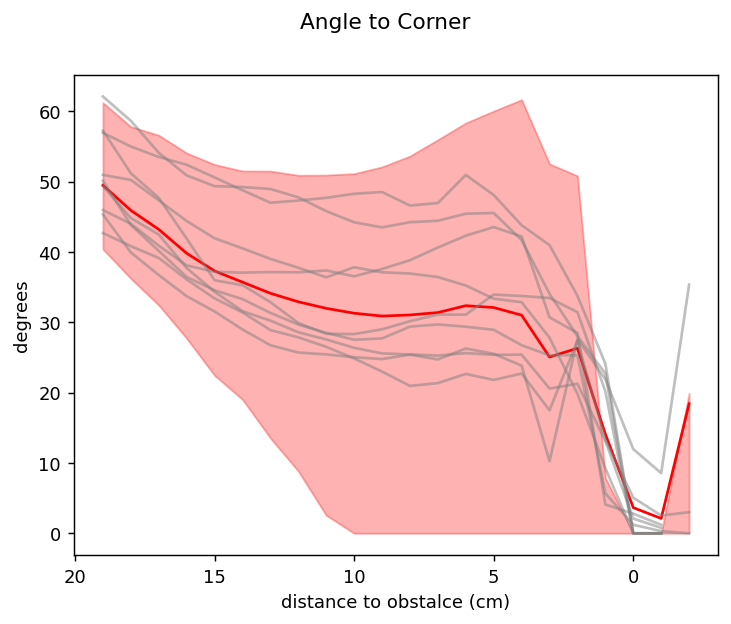

In [292]:
df = dark_long
df = drop_nans_in_columns(df,'obstacle_ind')
fig,ax = plt.subplots(dpi = 130)
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
fig.suptitle('Angle to Corner')
#ax.invert_xaxis()
#ax.invert_xaxis()

xnew =  np.arange(-2, 20, 1) 
xnew= np.flip(xnew)

#xnew= np.flip(xnew)

rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmean(angle_array,axis = 0)
ax.invert_xaxis()
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)
ax.fill_between(xnew, q1, q3, color='r', alpha=0.3, label='IQR')

for ani,ani_df in df.groupby(['animal']):
    rows = ani_df.shape[0]
    angle_array = np.empty([rows,xnew.size])
    angle_array[:] =np.nan
    for i,row in enumerate(ani_df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        interpolater = interp1d(x,y,bounds_error=False)
        ynew = interpolater(xnew)
        angle_array[i] = ynew
    angle_mean = np.nanmean(angle_array,axis = 0)
    angle_median= np.nanmedian(angle_array,axis = 0)

    ax.plot(xnew,angle_mean,color = 'grey',alpha = .5)
    median, q1, q3, iqr = calculate_quartiles(angle_array)
    #ax.fill_between(xnew, q1, q3, color='grey', alpha=0.3, label='IQR')
    

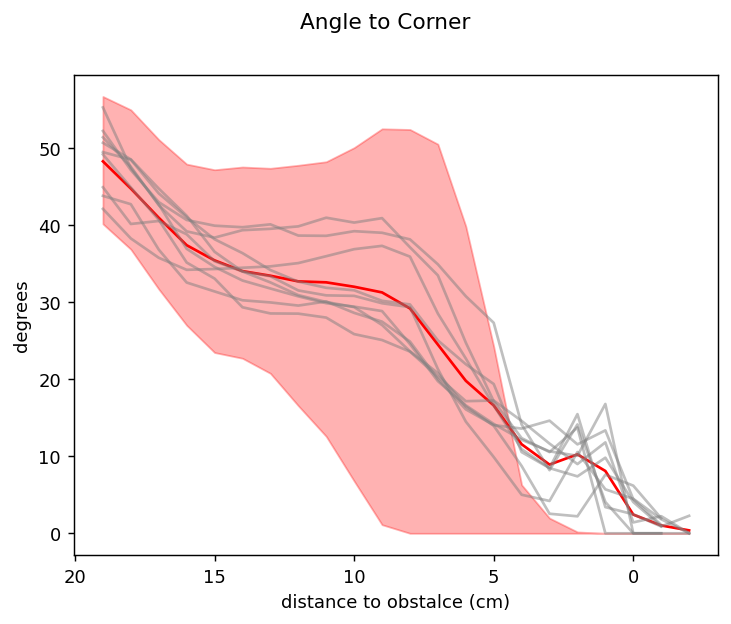

In [229]:
df = long[long.skill==  'early']
df = drop_nans_in_columns(df,'obstacle_ind')
fig,ax = plt.subplots(dpi = 130)
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
fig.suptitle('Angle to Corner')
#ax.invert_xaxis()
#ax.invert_xaxis()

xnew =  np.arange(-2, 20, 1) 
xnew= np.flip(xnew)

#xnew= np.flip(xnew)

rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmean(angle_array,axis = 0)
ax.invert_xaxis()
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)
ax.fill_between(xnew, q1, q3, color='r', alpha=0.3, label='IQR')

for ani,ani_df in df.groupby(['animal']):
    rows = ani_df.shape[0]
    angle_array = np.empty([rows,xnew.size])
    angle_array[:] =np.nan
    for i,row in enumerate(ani_df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        interpolater = interp1d(x,y,bounds_error=False)
        ynew = interpolater(xnew)
        angle_array[i] = ynew
    angle_mean = np.nanmean(angle_array,axis = 0)
    angle_median= np.nanmedian(angle_array,axis = 0)

    ax.plot(xnew,angle_mean,color = 'grey',alpha = .5)
    median, q1, q3, iqr = calculate_quartiles(angle_array)
    #ax.fill_between(xnew, q1, q3, color='grey', alpha=0.3, label='IQR')
    







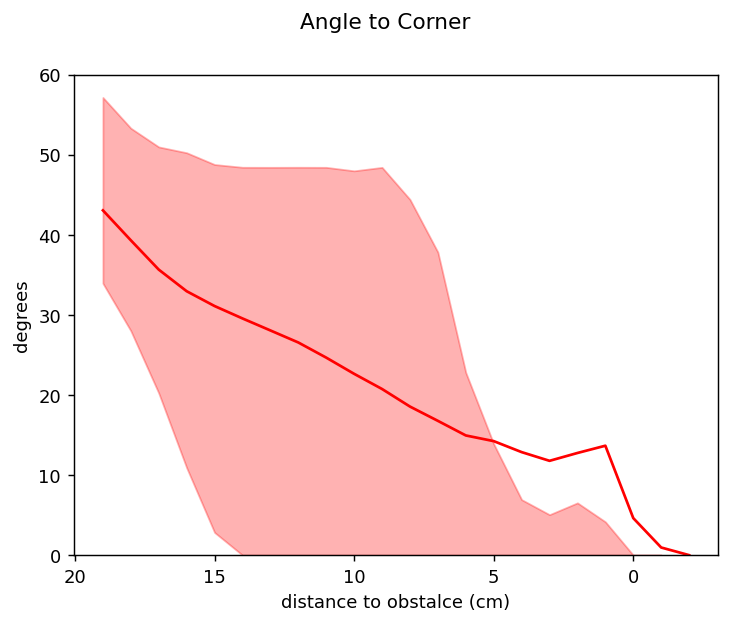

In [287]:
df = J701_long.sample(500)
df = drop_nans_in_columns(df,'obstacle_ind')
fig,ax = plt.subplots(dpi = 130)
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
ax.set_ylim(0,60)
fig.suptitle('Angle to Corner')
#ax.invert_xaxis()
#ax.invert_xaxis()

xnew =  np.arange(-2, 20, 1) 
xnew= np.flip(xnew)

#xnew= np.flip(xnew)

rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmean(angle_array,axis = 0)
angle_mean[np.isnan(angle_mean)] = 0
ax.invert_xaxis()
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)
ax.fill_between(xnew, q1, q3, color='r', alpha=0.3, label='IQR')

<AxesSubplot: xlabel='date'>

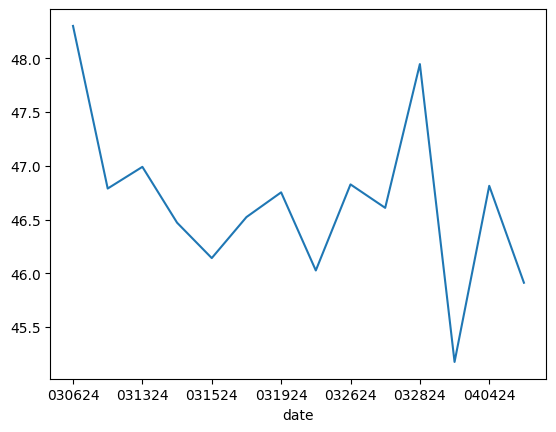

In [316]:
J701_df.groupby('date').mean().dist.plot()

<AxesSubplot: xlabel='date', ylabel='linearity'>

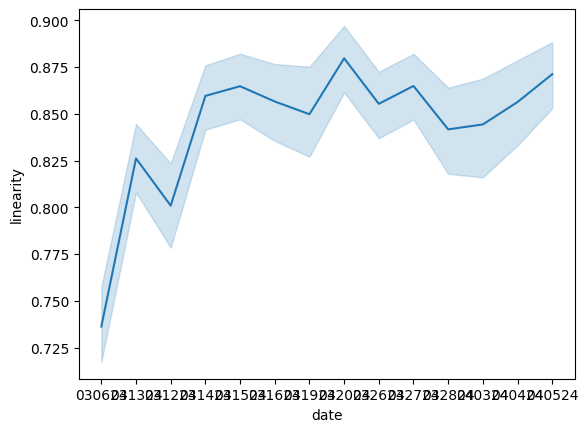

In [319]:
sns.lineplot(data=J701_df,x='date',y = 'linearity')

<AxesSubplot: xlabel='date'>

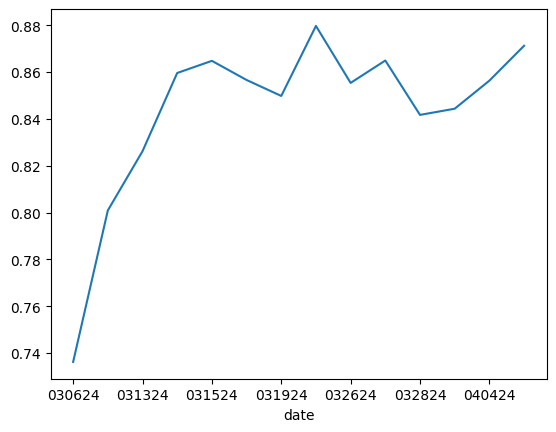

In [315]:
J701_df.groupby('date').mean().linearity.plot()

<AxesSubplot: xlabel='date'>

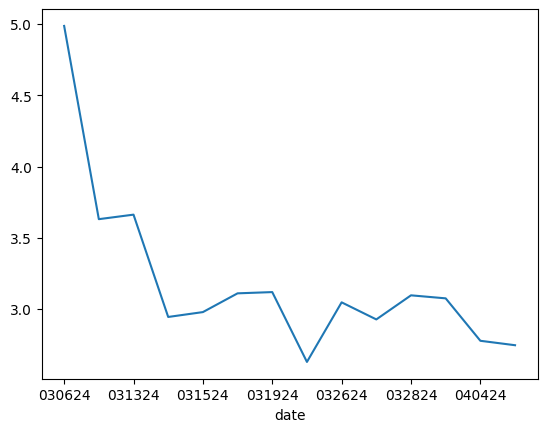

In [297]:
J701_df.groupby('date').mean().time.plot()

<AxesSubplot: xlabel='date', ylabel='time'>

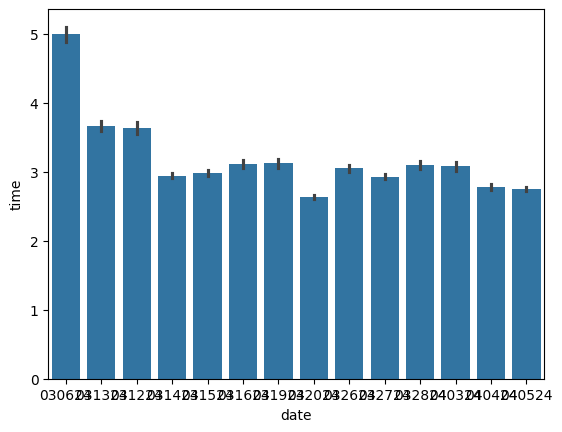

In [300]:
fig,ax = plt.subplots()
sns.barplot(data = J701_df, estimator='mean',errorbar = 'se',x = 'date',y = 'time')

In [314]:

for ani, anidf in J701_df.groupby('animal'):
    for date, datedf in anidf.groupby('date'):
        print(ani,date,len(datedf))

J701LT 030624 117
J701LT 031224 75
J701LT 031324 71
J701LT 031424 75
J701LT 031524 80
J701LT 031624 53
J701LT 031924 57
J701LT 032024 77
J701LT 032624 31
J701LT 032724 72
J701LT 032824 45
J701LT 040324 47
J701LT 040424 64
J701LT 040524 84
J701NN 030624 137
J701NN 031224 108
J701NN 031324 98
J701NN 031424 97
J701NN 031524 137
J701NN 031624 80
J701NN 031924 76
J701NN 032024 124
J701NN 032624 145
J701NN 032724 132
J701NN 032824 89
J701NN 040324 61
J701NN 040424 75
J701NN 040524 113
J701RN 030624 89
J701RN 031224 64
J701RN 031324 117
J701RN 031424 153
J701RN 031524 108
J701RN 031624 88
J701RN 031924 63
J701RN 032024 121
J701RN 032624 138
J701RN 032724 176
J701RN 032824 120
J701RN 040324 87
J701RN 040424 94
J701RN 040524 112
J701RT 030624 79
J701RT 031224 71
J701RT 031324 99
J701RT 031424 117
J701RT 031524 89
J701RT 031624 95
J701RT 031924 76
J701RT 032024 110
J701RT 032624 121
J701RT 032724 125
J701RT 032824 63
J701RT 040324 81
J701RT 040424 87
J701RT 040524 108


In [271]:
angle_mean

array([41.94945826, 38.12190503, 34.78404811, 32.02896347, 29.87632377,
       28.22730516, 26.81488965, 25.13640416, 23.35788317, 21.49921596,
       19.37455463, 17.10388101, 15.63758206, 14.09154965, 13.27646012,
       11.79103133, 10.37567111, 10.84175081, 11.08408847,  3.66094698,
        1.21740244, 61.23529291])

In [255]:
angle_mean[np.isnan(angle_mean)] = 0

TypeError: 'int' object does not support item assignment

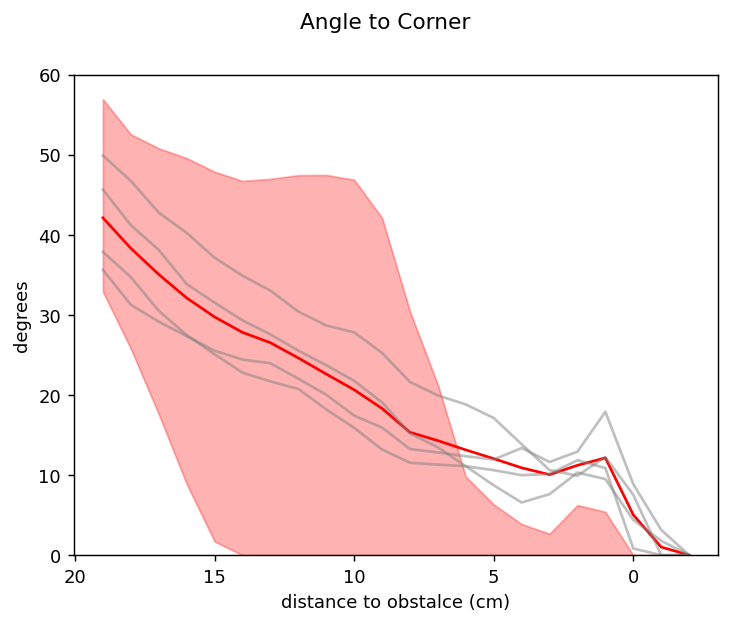

In [289]:
df = J701_long.sample(500)
df = drop_nans_in_columns(df,'obstacle_ind')
fig,ax = plt.subplots(dpi = 130)
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
ax.set_ylim(0,60)
fig.suptitle('Angle to Corner')
#ax.invert_xaxis()
#ax.invert_xaxis()

xnew =  np.arange(-2, 20, 1) 
xnew= np.flip(xnew)

#xnew= np.flip(xnew)

rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmean(angle_array,axis = 0)
angle_mean[np.isnan(angle_mean)] = 0
ax.invert_xaxis()
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)
ax.fill_between(xnew, q1, q3, color='r', alpha=0.3, label='IQR')

for ani,ani_df in df.groupby(['animal']):
    rows = ani_df.shape[0]
    angle_array = np.empty([rows,xnew.size])
    angle_array[:] =np.nan
    for i,row in enumerate(ani_df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        interpolater = interp1d(x,y,bounds_error=False)
        ynew = interpolater(xnew)
        angle_array[i] = ynew
    ani_angle_mean = np.nanmean(angle_array,axis = 0)
    ani_angle_mean[np.isnan(ani_angle_mean)] = 0
    angle_median= np.nanmedian(angle_array,axis = 0)

    ax.plot(xnew,ani_angle_mean,color = 'grey',alpha = .5)
    median, q1, q3, iqr = calculate_quartiles(angle_array)

In [253]:
angle_mean

array([49.8528915 , 46.0604338 , 42.14208379, 39.35839278, 36.49979936,
       34.29466219, 32.19972252, 29.81216165, 27.87653543, 25.91897619,
       23.52085819, 20.09156522, 17.83702198, 16.28154665, 14.80824951,
       12.35171255,  9.55108141,  8.76394934,  9.01655031,  4.49837857,
        0.        ,         nan])

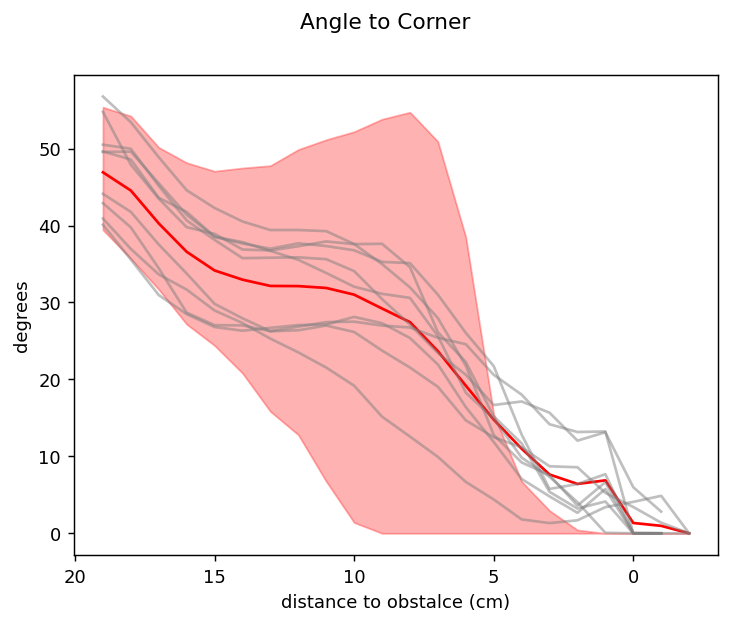

In [232]:
df = long[long.skill==  'middle']
df = drop_nans_in_columns(df,'obstacle_ind')
fig,ax = plt.subplots(dpi = 130)
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
fig.suptitle('Angle to Corner')
#ax.invert_xaxis()
#ax.invert_xaxis()

xnew =  np.arange(-2, 20, 1) 
xnew= np.flip(xnew)

#xnew= np.flip(xnew)

rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmean(angle_array,axis = 0)
ax.invert_xaxis()
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)
ax.fill_between(xnew, q1, q3, color='r', alpha=0.3, label='IQR')

for ani,ani_df in df.groupby(['animal']):
    rows = ani_df.shape[0]
    angle_array = np.empty([rows,xnew.size])
    angle_array[:] =np.nan
    for i,row in enumerate(ani_df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        interpolater = interp1d(x,y,bounds_error=False)
        ynew = interpolater(xnew)
        angle_array[i] = ynew
    angle_mean = np.nanmean(angle_array,axis = 0)
    angle_median= np.nanmedian(angle_array,axis = 0)

    ax.plot(xnew,angle_mean,color = 'grey',alpha = .5)
    median, q1, q3, iqr = calculate_quartiles(angle_array)
    #ax.fill_between(xnew, q1, q3, color='grey', alpha=0.3, label='IQR')

In [43]:
keys = list_columns(df,['gt'])
keys = [key for key in keys if 'cen' not in key]
for key in keys:
    df.loc[df.obstacle_cluster ==0,key] = df.loc[df.obstacle_cluster ==0,key].mean()

In [49]:
df.gt_obstacleTR_x_cm

2      27.172531
3      27.157091
4      36.333080
5      39.989990
6      39.977939
         ...    
135    39.354733
136    39.359810
138    39.123769
139    39.071872
140    26.836969
Name: gt_obstacleTR_x_cm, Length: 117, dtype: float64

In [48]:
list_columns(df,['obstacle'])


array(['obstacleTL_x', 'obstacleTL_y', 'obstacleTR_x', 'obstacleTR_y',
       'obstacleBR_x', 'obstacleBR_y', 'obstacleBL_x', 'obstacleBL_y',
       'obstacleTL_x_cm', 'obstacleTL_y_cm', 'obstacleTR_x_cm',
       'obstacleTR_y_cm', 'obstacleBR_x_cm', 'obstacleBR_y_cm',
       'obstacleBL_x_cm', 'obstacleBL_y_cm', 'gt_obstacleTL_x',
       'gt_obstacleTL_y', 'gt_obstacleTR_x', 'gt_obstacleTR_y',
       'gt_obstacleBR_x', 'gt_obstacleBR_y', 'gt_obstacleBL_x',
       'gt_obstacleBL_y', 'gt_obstacleTL_x_cm', 'gt_obstacleTL_y_cm',
       'gt_obstacleTR_x_cm', 'gt_obstacleTR_y_cm', 'gt_obstacleBR_x_cm',
       'gt_obstacleBR_y_cm', 'gt_obstacleBL_x_cm', 'gt_obstacleBL_y_cm',
       'gt_obstacle_cen_x', 'gt_obstacle_cen_x_cm', 'gt_obstacle_cen_y',
       'gt_obstacle_cen_y_cm', 'obstacle_cluster',
       'mean_gt_obstacle_cen_x_cm', 'mean_gt_obstacle_cen_y_cm',
       'obstacle_ind', 'obstacle_nose_x', 'obstacle_nose_y',
       'obstacle_basis_start_x', 'obstacle_basis_start_y',
       'obsta

In [45]:
obstacle_x = pd.unique(df[['mean_gt_obstacleTL_x_cm',
        'mean_gt_obstacleTR_x_cm','mean_gt_obstacleBR_x_cm',
        'mean_gt_obstacleBL_x_cm',
        'mean_gt_obstacleTL_x_cm']].values.ravel('K'))

KeyError: "None of [Index(['mean_gt_obstacleTL_x_cm', 'mean_gt_obstacleTR_x_cm',\n       'mean_gt_obstacleBR_x_cm', 'mean_gt_obstacleBL_x_cm',\n       'mean_gt_obstacleTL_x_cm'],\n      dtype='object')] are in the [columns]"

In [7]:
KMeans(n_clusters=6).fit(kmeans_input).labels_


AttributeError: 'NoneType' object has no attribute 'split'

In [9]:
KMeans(n_clusters=6).fit(kmeans_input)



AttributeError: 'NoneType' object has no attribute 'split'

In [13]:
kmeans_input

array([[23.29036032, 23.31557719],
       [23.22465815, 23.31161158],
       [31.64079869, 22.91979216],
       [36.83802189, 16.26371643],
       [36.88626046, 16.30126351],
       [36.85449767, 16.25090379],
       [36.91564214, 16.30083012],
       [36.82231722, 16.28635706],
       [36.83498796, 16.28736465],
       [36.82238453, 16.29544288],
       [36.83248172, 16.28587434],
       [36.83551871, 16.2643826 ],
       [36.8341293 , 16.29035869],
       [37.00786845, 16.33048534],
       [37.00121326, 16.34954274],
       [37.0105126 , 16.33032402],
       [38.11408501, 29.39524574],
       [38.0821265 , 29.42633795],
       [21.97759824, 30.02958456],
       [22.02244281, 30.01090827],
       [22.00601994, 29.99925793],
       [36.82000318, 16.38100795],
       [36.81063677, 16.31920432],
       [36.81074563, 16.34732577],
       [36.79621902, 16.33471515],
       [25.33711226, 22.30593035],
       [25.31142239, 22.36812249],
       [25.3343497 , 22.35039051],
       [23.72822677,

In [10]:
kmeans_input = np.vstack([df['gt_obstacle_cen_x_cm'].values, df['gt_obstacle_cen_y_cm'].values])

In [12]:
df = df[df['gt_obstacle_cen_x_cm'].notna()]
kmeans_input = np.vstack([df['gt_obstacle_cen_x_cm'].values, df['gt_obstacle_cen_y_cm'].values])
kmeans_input = np.transpose(kmeans_input).astype(float)
labels = KMeans(n_clusters=6).fit(kmeans_input).labels_
df['obstacle_cluster'] = labels


AttributeError: 'NoneType' object has no attribute 'split'

In [2]:
from obstacle_avoidance_processing import AvoidanceProcessing


# metadata json path

metadata_path = r"D:\obstacle_avoidance\metadata\J701_704\test_J701_oa.json"


#C:\Users\nlab\Desktop\mike_bonsai\recordings\metadata
# task name
# 'oa' for object avoidance
# 'gd' for gap detection

task_name = 'oa'

session = AvoidanceProcessing(metadata_path, task=task_name) 
session.change_dlc_project(r"D:\obstacle_avoidance\deeplabcut\obstacle_obstacle_avoidance_070124-Mike-2024-07-01\config.yaml")
session.dlc_project
#session.preprocess()
session.process()

0it [00:00, ?it/s]

75
df made
pxl
odd_even
trial_start
smooth_ts
dist
ob_cen
start


1it [00:15, 15.72s/it]

distance


In [127]:
row.ts_distance_from_edge

array([8.439080427408198, 8.344662177154873, 8.165239797860067,
       7.91719865047877, 7.620125849111973, 7.293210175336693,
       6.952672125351535, 6.610378468566173, 6.273372834313982,
       5.944205783414528, 5.62193477377733, 5.3036464676869635,
       4.986109933725185, 4.667038678944889, 4.34571125058984,
       4.0229082897473685, 3.7003703527469796, 3.380057951647597,
       3.0633832246380166, 2.750580726087332, 2.4403246163400283,
       2.1297300836128414, 1.814863099623821, 1.491666314136907,
       1.1570203190589474, 0.8095124829758085, 0.44958804316028633,
       0.07907755119516935, -0.2996378559699764, -0.6845235190953929,
       -1.0745566922660785, -1.515600799403784, -2.0424588952258986,
       -2.5955683312190647, -3.150017060722969, -3.6957747769825335,
       -4.231854454864744, -4.764363425402794, -5.3040604532866,
       -5.862916488824639, -6.4507204154571465, -7.072896533363992,
       -7.729879784015242, -8.417774436968953, -9.129816195907448,
       -9

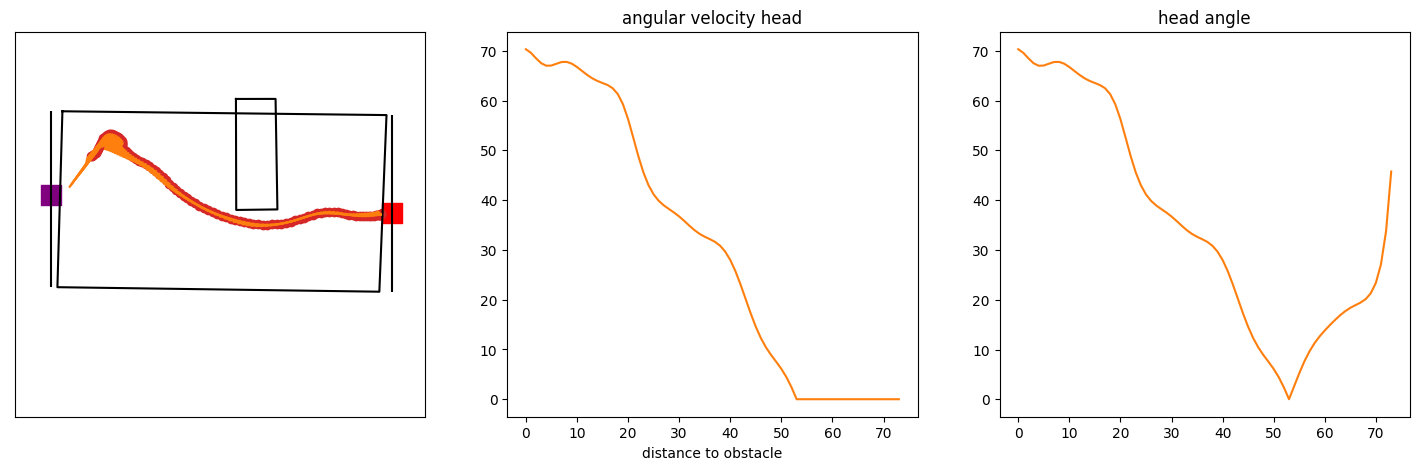

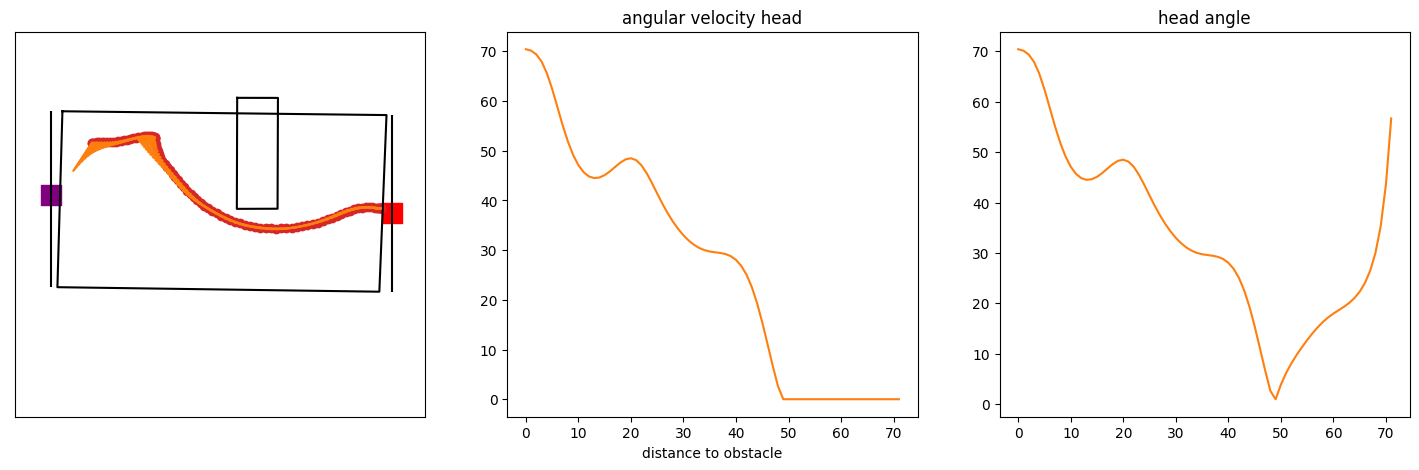

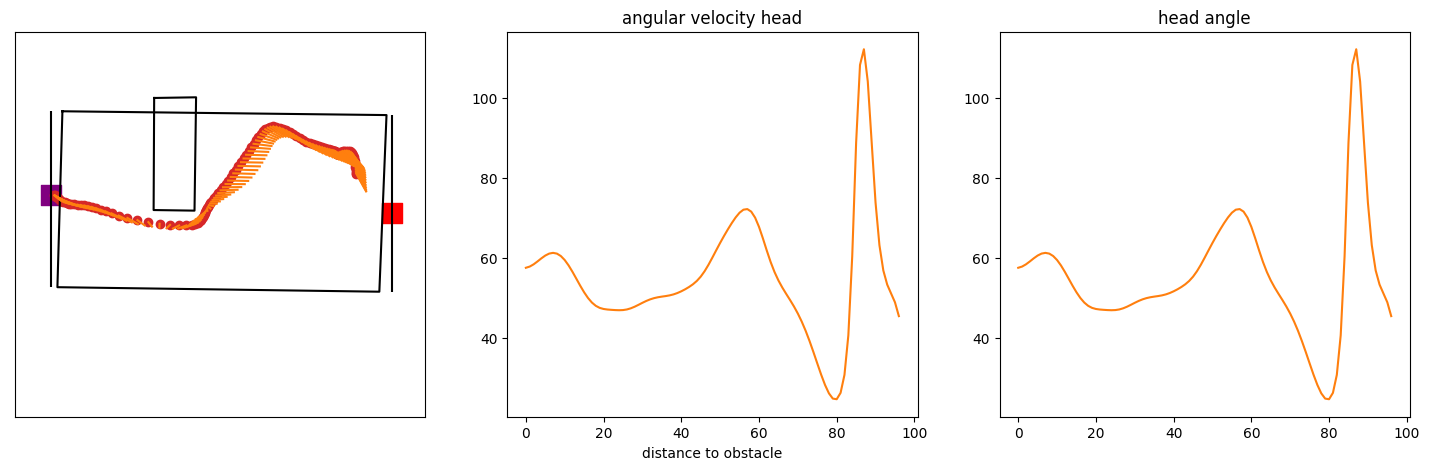

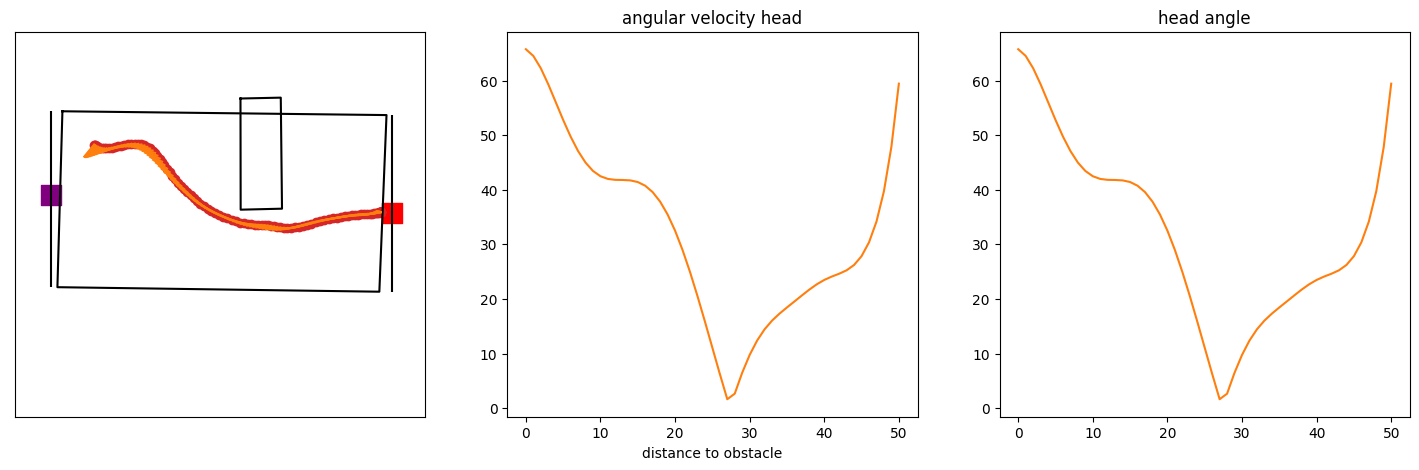

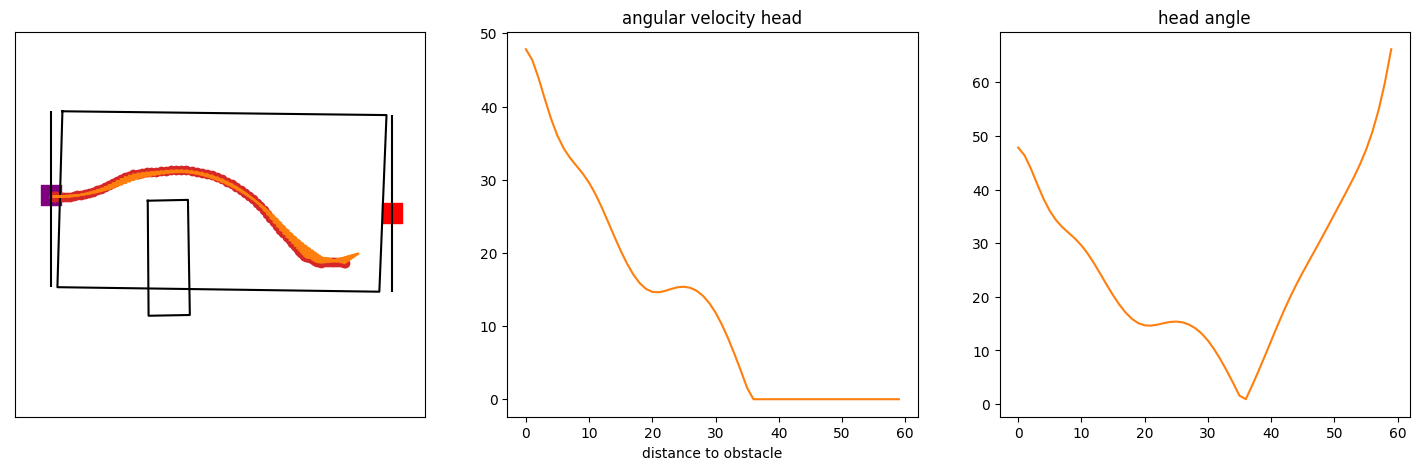

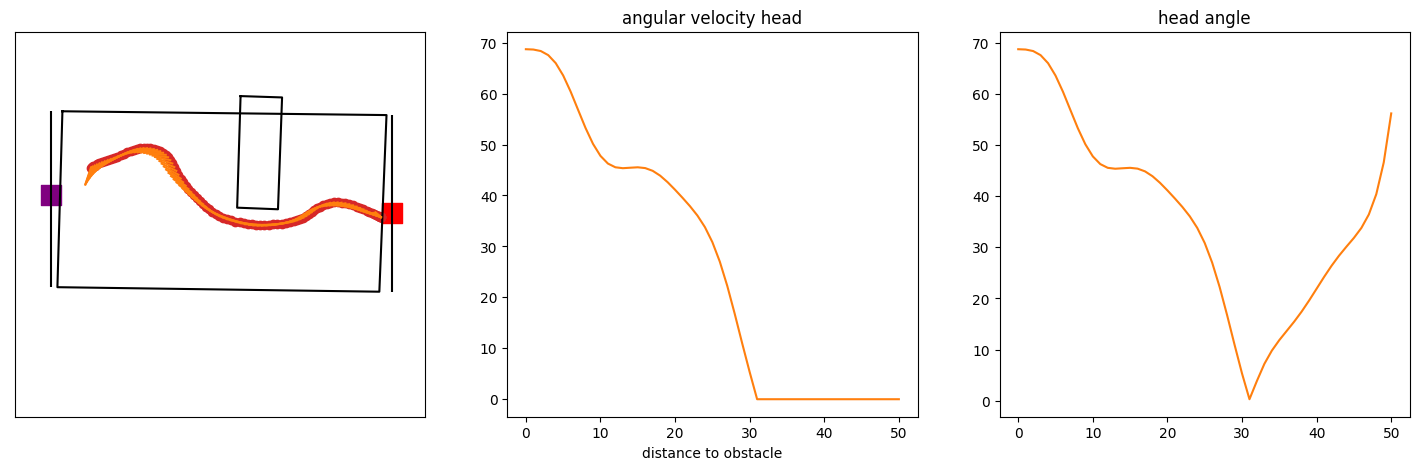

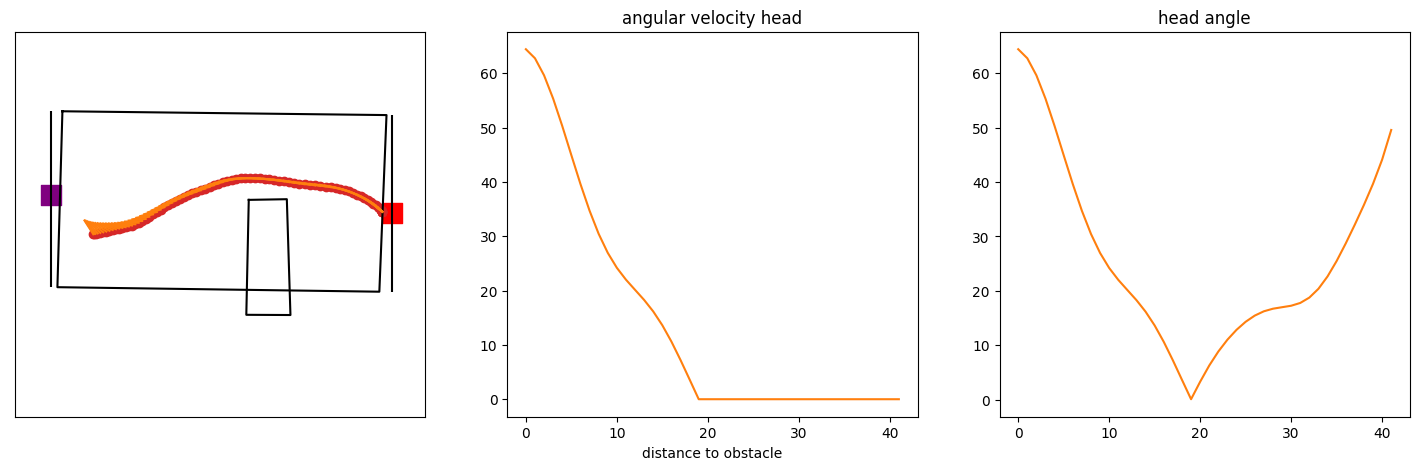

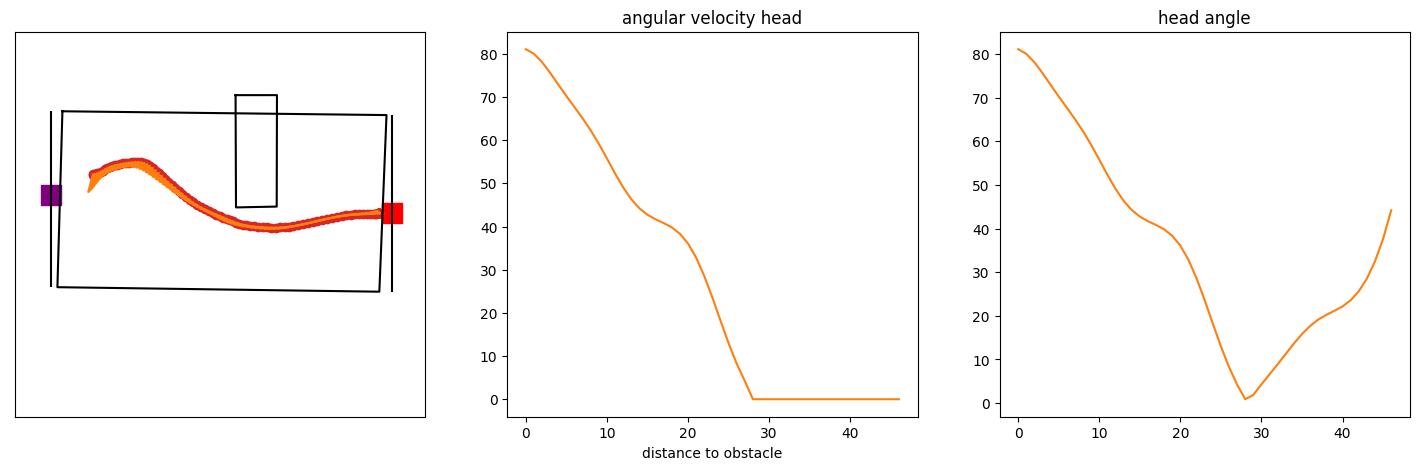

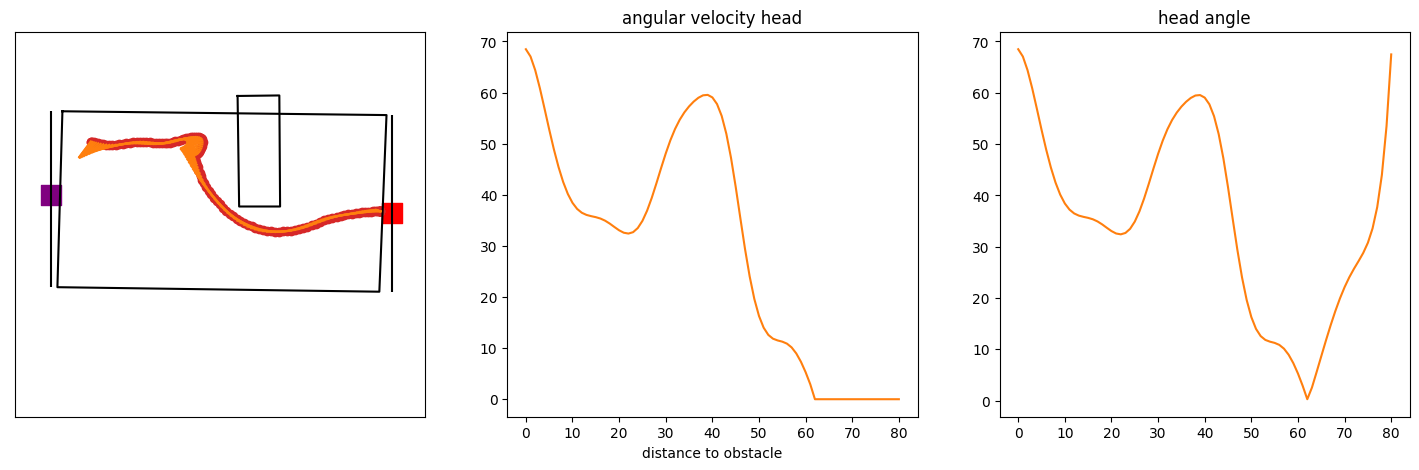

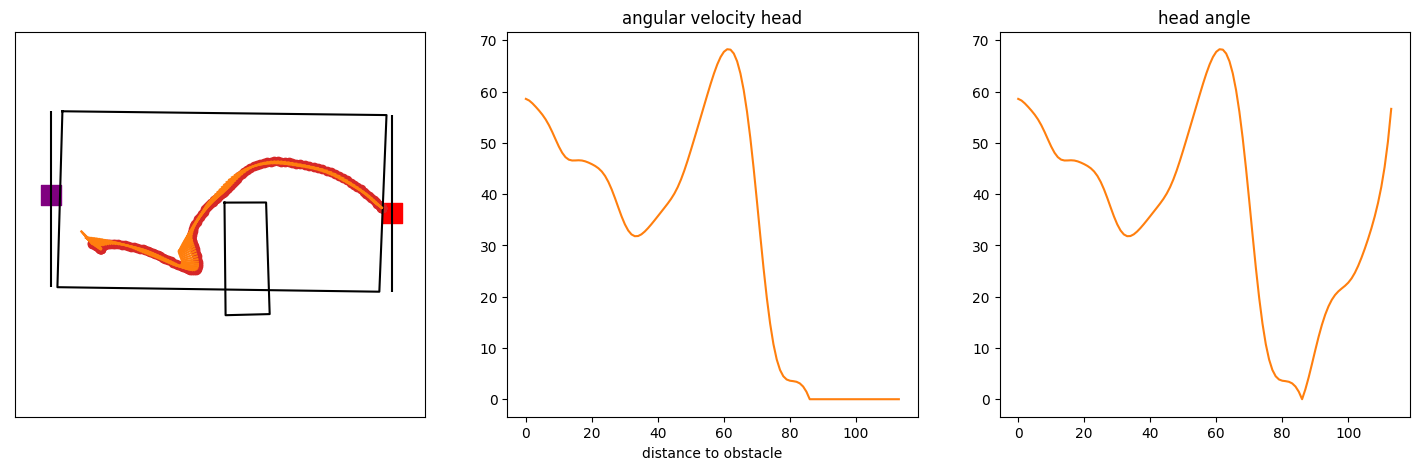

In [165]:
test = long.sample(10)
for ind,row in test.iterrows():
    
        
    fig,ax = plt.subplots(1,3,figsize=(18,5))
    ax[0].set_xticks([])
    ax[0].set_yticks([])
   
    #ax[1].set_xlim(20,0)
    #ax[1].invert_xaxis()
   # ax[2].set_xlim(20,0)
    if row.task == 'oadark':
        ax[0].set_facecolor('grey') 
        ax[0].patch.set_alpha(.4)
    else:
        None


    trial_df = test.loc[[ind]]
    plot_arena(test,ax[0])
    plot_orginal_obstacle(trial_df,ax[0],int(row.obstacle_cluster))



    #ax[0].set_title()
   
    ax[1].set_title('angular velocity head')
    ax[2].set_title('head angle')
   
    #ax[1].set_ylim(-12,2)
    ax[1].set_xlabel('distance to obstacle')
    

  
    ax[0].plot((row.ts_nose_x_cm,row.ts_spine_x_cm),(row.ts_nose_y_cm,row.ts_spine_y_cm),color = 'tab:orange')
      
    ax[0].scatter((row.ts_nose_x_cm),(row.ts_nose_y_cm),color = 'tab:red')
    ax[1].plot(row.ts_zero_out_angle_to_corner[:int(row.obstacle_ind)],color = 'tab:orange')
    ax[2].plot(row.ts_angle_to_corner[:int(row.obstacle_ind)],color = 'tab:orange')
    thresh = np.argwhere(row.ts_distance_from_edge[:int(row.obstacle_ind)]<=15).min()
  
    min = np.argmin(row.head_angle_velocity[thresh:int(row.obstacle_ind)])
    max = np.argmax(row.head_angle_velocity[thresh:int(row.obstacle_ind)])

In [191]:
oa_session = plot_oa(r"D:\obstacle_avoidance\metadata\J701_704\test_batch_J701_oa.json",'blank')
oa_session.gather_session_df('obstacle',6)
oa_df = oa_session.df

6


In [307]:
oa_session = plot_oa(r'D:\obstacle_avoidance\metadata\J701\oa_J701.json','blank')
oa_session.gather_session_df('obstacle',6)
J701_df = oa_session.df

6


In [304]:
pd.read_hdf(r"D:\obstacle_avoidance\recordings\031524\J701RT\oa\processed_J701RT_031524_oa.h5")

,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,rightear_y,...,goal_basis_end_y,obstacle_devations,goal_devations,lateral_error,ts_lateral_error_to_target_port,tortuosity,linearity,head_angle,head_angle_velocity,time
0,56442.242291,56443.790656,"[56442.251187, 56442.267916, 56442.284876, 564...","[75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 8...","[88.1075439453125, 88.35302734375, 89.50109100...","[220.01828002929688, 217.25450134277344, 216.7...","[93.71064758300781, 94.08599853515625, 95.8514...","[235.95138549804688, 235.37905883789062, 234.8...","[106.8557357788086, 108.23158264160156, 109.71...","[224.90643310546875, 224.4191131591797, 224.32...",...,22.927133,"[nan, 22.487807198843306, 21.185807563238995, ...","[nan, 29.777114992779875, 29.642171169869716, ...",NaN,"[7.081150869987281, 7.14259331888989, 7.254589...",1.005746,0.994287,"[66.51727039264333, 65.6802789558371, 64.04217...","[-0.8764953829959943, -1.7154181278090475, -2....",1.533333
2,56451.819558,56456.628480,"[56451.821824, 56451.837696, 56451.854412, 564...","[649, 650, 651, 652, 653, 654, 655, 656, 657, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[96.81970977783203, 96.97228240966797, 96.8436...","[233.20758056640625, 233.7234649658203, 233.59...","[99.94224548339844, 99.93916320800781, 100.237...","[214.65673828125, 214.71229553222656, 214.4557...",...,21.859895,"[nan, 9.296569867549943, 9.656871147599139, 10...","[nan, 31.06518821291789, 30.798279412568423, 3...","[-7.886597878282696, -7.839751389641432, -7.75...","[3.90197901335857, 3.8551325247173054, 3.76881...",1.321213,0.756880,"[-51.94263382446538, -50.59578730780025, -48.0...","[1.4104143740893926, 2.6461824498549524, 3.567...",4.800000
3,56456.628480,56459.352768,"[56456.639334, 56456.65632, 56456.672947, 5645...","[[938, 939, 940, 941, 942, 943, 944, 945, 946,...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[651.1929931640625, 651.519287109375, 651.9112...","[246.5821990966797, 247.43316650390625, 247.15...","[646.0567626953125, 647.06689453125, 647.86767...","[266.1788635253906, 266.8865966796875, 267.231...",...,20.245333,"[nan, 49.46189733709904, 48.49019701962526, 47...","[nan, 12.310599744608908, 11.32935972306684, 1...","[-12.08780596306745, -12.137040597045072, -12....","[11.35802747984194, 11.407262113819563, 11.494...",1.046954,0.955152,"[-55.15376770102236, -54.22413763741349, -52.4...","[0.9735063261299493, 1.8907734873069026, 2.708...",2.700000
4,56459.352768,56463.268800,"[56459.35744, 56459.373504, 56459.390336, 5645...","[1101, 1102, 1103, 1104, 1105, 1106, 1107, 110...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[94.22369384765625, 93.57816314697266, 94.0027...","[234.4278106689453, 234.43472290039062, 234.07...","[100.15300750732422, 99.78837585449219, 100.30...","[215.49009704589844, 215.4086151123047, 215.36...",...,23.194957,"[nan, 26.210588479631525, 26.466477202802547, ...","[nan, 7.389235411064257, 6.7418010296898085, 6...","[4.542731491939861, 4.598617511654098, 4.70574...","[3.983782145289439, 4.039668165003675, 4.14679...",1.099736,0.909309,"[-46.05108854093127, -45.65594230592637, -44.9...","[0.41379616966168653, 0.790260609993072, 1.101...",3.900000
5,56463.268800,56465.894502,"[56463.27534, 56463.292441, 56463.309209, 5646...","[[1336, 1337, 1338, 1339, 1340, 1341, 1342, 13...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[648.49267578125, 649.3883056640625, 649.63183...","[255.4394989013672, 255.1424102783203, 255.185...","[655.7060546875, 656.482177734375, 656.9983520...","[275.2025146484375, 274.4612731933594, 274.545...",...,18.963782,"[nan, 10.736937992386837, 10.190728615921303, ...","[nan, 19.497331501274864, 19.036545548174626, ...","[6.9909597589643795, 7.030

In [308]:
J701_df[(J701_df['animal']=='J701RT') &(J701_df['date']=='031524') ]

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,mad_interp_ts_nose_y_cm,animal_mean_interp_ts_nose_y_cm,animal_median_interp_ts_nose_y_cm,animal_std_interp_ts_nose_y_cm,animal_mad_interp_ts_nose_y_cm,date_mean_interp_ts_nose_y_cm,date_median_interp_ts_nose_y_cm,date_std_interp_ts_nose_y_cm,date_mad_interp_ts_nose_y_cm,ts_inds
1647,0,56442.242291,56443.790656,"[56442.251187, 56442.267916, 56442.284876, 564...","[75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 8...","[88.1075439453125, 88.35302734375, 89.50109100...","[220.01828002929688, 217.25450134277344, 216.7...","[93.71064758300781, 94.08599853515625, 95.8514...","[235.95138549804688, 235.37905883789062, 234.8...","[106.8557357788086, 108.23158264160156, 109.71...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 2..."
1648,2,56451.819558,56456.628480,"[56451.821824, 56451.837696, 56451.854412, 564...","[649, 650, 651, 652, 653, 654, 655, 656, 657, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[96.81970977783203, 96.97228240966797, 96.8436...","[233.20758056640625, 233.7234649658203, 233.59...","[99.94224548339844, 99.93916320800781, 100.237...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 8..."
1649,3,56456.628480,56459.352768,"[56456.639334, 56456.65632, 56456.672947, 5645...","[[938, 939, 940, 941, 942, 943, 944, 945, 946,...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[651.1929931640625, 651.519287109375, 651.9112...","[246.5821990966797, 247.43316650390625, 247.15...","[646.0567626953125, 647.06689453125, 647.86767...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 8..."
1650,4,56459.352768,56463.268800,"[56459.35744, 56459.373504, 56459.390336, 5645...","[1101, 1102, 1103, 1104, 1105, 1106, 1107, 110...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[94.22369384765625, 93.57816314697266, 94.0027...","[234.4278106689453, 234.43472290039062, 234.07...","[100.15300750732422, 99.78837585449219, 100.30...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[146, 147, 148, 149, 150, 151, 152, 153, 154, ..."
1651,5,56463.268800,56465.894502,"[56463.27534, 56463.292441, 56463.309209, 5646...","[[1336, 1337, 1338, 1339, 1340, 1341, 1342, 13...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[648.49267578125, 649.3883056640625, 649.63183...","[255.4394989013672, 255.1424102783203, 255.185...","[655.7060546875, 656.482177734375, 656.9983520...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 8..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1731,102,56795.118208,56797.813593,"[56795.123494, 56795.14016, 56795.157376, 5679...","[21240, 21241, 21242, 21243, 21244, 21245, 212...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[86.88262939453125, 86.29395294189453, 86.2537...","[243.6265106201172, 243.3895263671875, 243.870...","[96.18431091308594, 94.98956298828125, 94.1565...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 4..."
1732,103,56797.813593,56800.443302,"[56797.824755, 56797.841356, 56797.857958, 567...","[[21402, 21403, 21404, 21405, 21406, 21407, 21...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[648.9658203125, 648.6309814453125, 648.436645...","[235.25808715820312, 236.4067840576172, 236.91...","[642.1846313476562, 641.1429443359375, 641.831...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 7..."
1733,109,56848.551001,56852.278758,"[56848.559052, 56848.575603, 56848.592115, 568...","[[2

In [306]:
J701_df[(J701_df['animal']=='J701RT') &(J701_df['date']=='031524') ]

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,mad_interp_ts_nose_y_cm,animal_mean_interp_ts_nose_y_cm,animal_median_interp_ts_nose_y_cm,animal_std_interp_ts_nose_y_cm,animal_mad_interp_ts_nose_y_cm,date_mean_interp_ts_nose_y_cm,date_median_interp_ts_nose_y_cm,date_std_interp_ts_nose_y_cm,date_mad_interp_ts_nose_y_cm,ts_inds
1649,3,56456.628480,56459.352768,"[56456.639334, 56456.65632, 56456.672947, 5645...","[[938, 939, 940, 941, 942, 943, 944, 945, 946,...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[651.1929931640625, 651.519287109375, 651.9112...","[246.5821990966797, 247.43316650390625, 247.15...","[646.0567626953125, 647.06689453125, 647.86767...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 8..."
1650,4,56459.352768,56463.268800,"[56459.35744, 56459.373504, 56459.390336, 5645...","[1101, 1102, 1103, 1104, 1105, 1106, 1107, 110...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[94.22369384765625, 93.57816314697266, 94.0027...","[234.4278106689453, 234.43472290039062, 234.07...","[100.15300750732422, 99.78837585449219, 100.30...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[146, 147, 148, 149, 150, 151, 152, 153, 154, ..."
1651,5,56463.268800,56465.894502,"[56463.27534, 56463.292441, 56463.309209, 5646...","[[1336, 1337, 1338, 1339, 1340, 1341, 1342, 13...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[648.49267578125, 649.3883056640625, 649.63183...","[255.4394989013672, 255.1424102783203, 255.185...","[655.7060546875, 656.482177734375, 656.9983520...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 8..."
1652,6,56465.894502,56469.097779,"[56465.909299, 56465.925926, 56465.943539, 564...","[1494, 1495, 1496, 1497, 1498, 1499, 1500, 150...","[83.90828704833984, 84.04754638671875, 84.2902...","[217.48377990722656, 217.3411102294922, 216.96...","[90.40934753417969, 90.4156265258789, 90.48732...","[235.21583557128906, 235.3313751220703, 234.99...","[102.47850036621094, 102.2491683959961, 102.45...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[105, 106, 107, 108, 109, 110, 111, 112, 113, ..."
1654,8,56471.617113,56474.558425,"[56471.627865, 56471.644659, 56471.661849, 564...","[1837, 1838, 1839, 1840, 1841, 1842, 1843, 184...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[92.56877899169922, 92.22736358642578, 91.8719...","[234.23284912109375, 233.8502960205078, 234.21...","[100.46745300292969, 101.01390075683594, 101.0...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[104, 105, 106, 107, 108, 109, 110, 111, 112, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1730,101,56793.098700,56795.118208,"[56793.106188, 56793.122995, 56793.13975, 5679...","[[21119, 21120, 21121, 21122, 21123, 21124, 21...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[644.1448974609375, 644.0680541992188, 643.963...","[244.60267639160156, 244.6567840576172, 244.90...","[644.3128051757812, 646.0863647460938, 646.826...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 4..."
1732,103,56797.813593,56800.443302,"[56797.824755, 56797.841356, 56797.857958, 567...","[[21402, 21403, 21404, 21405, 21406, 21407, 21...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[648.9658203125, 648.6309814453125, 648.436645...","[235.25808715820312, 236.4067840576172, 236.91...","[642.1846313476562, 641.1429443359375, 641.831...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 7..."
1733,109,56848.551001,56852.278758,"[56848.559052, 56848.575603, 56848.592115, 568...","[[2

In [173]:
oa_df

,index,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,mean_gt_obstacleBL_x,mean_gt_obstacleBL_y,mean_gt_obstacleTL_x_cm,mean_gt_obstacleTL_y_cm,mean_gt_obstacleTR_x_cm,mean_gt_obstacleTR_y_cm,mean_gt_obstacleBR_x_cm,mean_gt_obstacleBR_y_cm,mean_gt_obstacleBL_x_cm,mean_gt_obstacleBL_y_cm
0,2,54888.700224,54891.883097,"[54888.700544, 54888.718284, 54888.733964, 548...","[718, 719, 720, 721, 722, 723, 724, 725, 726, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[81.01109313964844, 80.093505859375, 78.953483...","[267.2747802734375, 267.2362060546875, 267.059...","[76.46923065185547, 76.31986236572266, 76.1114...",...,252.163194,351.978534,21.583925,14.686678,27.708421,14.742512,27.087874,29.782308,21.323401,29.765219
1,3,54891.883097,54894.328614,"[54891.885043, 54891.901785, 54891.919104, 548...","[[909, 910, 911, 912, 913, 914, 915, 916, 917,...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[646.8807983398438, 647.6458740234375, 649.156...","[273.221923828125, 272.8769226074219, 272.9534...","[649.872802734375, 650.2636108398438, 651.1658...",...,252.163194,351.978534,21.583925,14.686678,27.708421,14.742512,27.087874,29.782308,21.323401,29.765219
4,6,54901.030297,54904.581644,"[54901.038297, 54901.054937, 54901.072345, 549...","[1458, 1459, 1460, 1461, 1462, 1463, 1464, 146...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[73.80955505371094, 73.48487854003906, 73.8060...","[271.5731506347656, 271.76324462890625, 272.24...","[80.69176483154297, 80.84627532958984, 80.8314...",...,393.945245,279.486166,33.385996,8.835824,39.392927,8.869718,39.409948,23.488870,33.314933,23.635255
5,7,54904.581644,54907.526950,"[54904.589504, 54904.606208, 54904.623513, 549...","[[1671, 1672, 1673, 1674, 1675, 1676, 1677, 16...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.1221923828125, 648.2233276367188, 649.514...","[273.9601135253906, 272.9598083496094, 272.274...","[649.3727416992188, 650.3615112304688, 651.541...",...,393.945245,279.486166,33.385996,8.835824,39.392927,8.869718,39.409948,23.488870,33.314933,23.635255
6,8,54907.526950,54911.328409,"[54907.540377, 54907.557171, 54907.5744, 54907...","[1848, 1849, 1850, 1851, 1852, 1853, 1854, 185...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[73.7158203125, 72.8050537109375, 72.790313720...","[270.97088623046875, 271.13671875, 270.6330566...","[81.20374298095703, 80.63900756835938, 80.5448...",...,393.945245,279.486166,33.385996,8.835824,39.392927,8.869718,39.409948,23.488870,33.314933,23.635255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,119,57082.762560,57085.777280,"[57082.764761, 57082.781171, 57082.797772, 570...","[[31303, 31304, 31305, 31306, 31307, 31308, 31...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[646.99169921875, 647.3726196289062, 648.58062...","[276.63037109375, 276.0502624511719, 275.97735...","[650.4732666015625, 650.9284057617188, 651.809...",...,228.850418,441.413714,19.683252,22.016949,25.762223,22.114254,25.455051,37.411560,19.359887,37.342780
211,121,57091.143552,57096.399091,"[57091.150873, 57091.167296, 57091.183961, 570...","[[31806, 31807, 31808, 31809, 31810, 31811, 31...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[648.8486328125, 649.8554077148438, 650.224731...","[274.8608703613281, 274.4029235839844, 274.232...","[648.9662475585938, 649.3734741210938, 650.165...",...,241.827041,278.823588,20.479146,8.707862,26.845233,8.725087,26.463115,23.661071,20.465212,23.596198
212,122,57096.399091,57099.115008,"[57096.402675, 57096.419136, 57

In [177]:
def get_ob_distance_from_mean_center(df):
    df['mean_center_x'] = np.nan
    df['mean_center_y'] = np.nan
    for cluster,cluter_df in df.groupby(['obstacle_cluster']):
        gt_label = cluter_df['obstacle_cluster'].astype(int).tolist()
        obstacle_xpos = np.array(cluter_df.loc[:,'gt_obstacle_cen_x_cm'])
        obstacle_ypos = np.array(cluter_df.loc[:,'gt_obstacle_cen_y_cm'])
        obstacle_xypos_ar = np.stack((obstacle_xpos, obstacle_ypos))
        mean_x =np.nanmean(obstacle_xpos)
        mean_y = np.nanmean(obstacle_ypos)
        df['mean_center_x'][df['obstacle_cluster']==cluster]  = mean_x
        df['mean_center_y'][df['obstacle_cluster']==cluster]  = mean_y
    for ind,row in df.iterrows():
        distance_from_mean_center = calculate_distances(np.array(row.gt_obstacle_cen_x_cm),
                                                        np.array(row.gt_obstacle_cen_y_cm),row.mean_center_x,row.mean_center_y)
        df.at[ind,'distance_from_mean_center'] = distance_from_mean_center

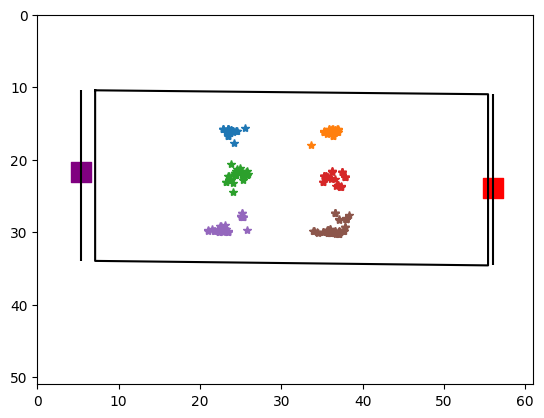

<Figure size 640x480 with 0 Axes>

In [197]:
import matplotlib.colors as mcolors
fig,ax = plt.subplots()
plt.figure()
for ind,row in oa_df.iterrows():
    ax.plot(row.gt_obstacle_cen_x_cm, row.gt_obstacle_cen_y_cm, '*', color=list(mcolors.TABLEAU_COLORS)[row.obstacle_cluster])
ax.set_ylim([51,0]); ax.set_xlim([0, 61])
plot_arena(oa_df,ax)




In [ ]:
cluster_label = test['obstacle_cluster'].tolist()
plt.figure()
for i in range(len(test2['obstacle_cluster'])):
    obstacles = kmeans_input[:,i]
    plt.plot(obstacles[0], obstacles[1], '*', color=list(mcolors.TABLEAU_COLORS)[cluster_label[i]])
    plt.ylim([20.03, 0]); plt.xlim([0, 33.30])

In [ ]:
for ind,row in oa_df:
    

In [202]:
get_ob_distance_from_mean_center(oa_df)

In [246]:
oa_df[['arenaTL_x_cm',
    'arenaTR_x_cm','arenaTR_x_cm',
    'arenaTL_x_cm',
    'arenaTL_x_cm']].values.ravel('K')

array([7.07054634, 7.07054634, 7.07054634, ..., 7.25234437, 7.25234437,
       7.25234437])

In [243]:
arena_x = oa_df[['arenaTL_x_cm',
    'arenaTR_x_cm','arenaTR_x_cm',
    'arenaTL_x_cm',
    'arenaTL_x_cm']].median().values.ravel('K')

In [244]:
arena_x

array([ 7.10722919, 55.42869874, 55.42869874,  7.10722919,  7.10722919])

<AxesSubplot: >

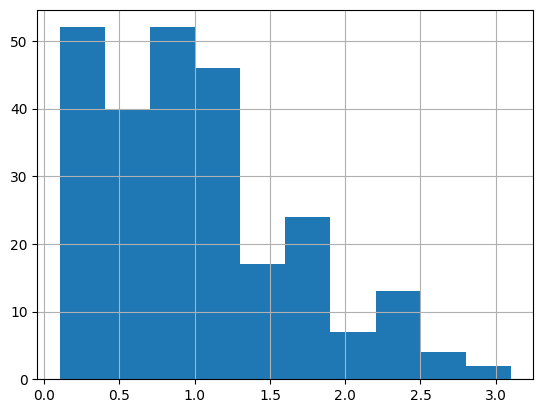

In [203]:
oa_df.distance_from_mean_center.hist()

In [249]:
pd.unique(oa_df[['gt_obstacleTL_y_cm',
    'gt_obstacleTR_y_cm','gt_obstacleBR_y_cm',
    'gt_obstacleBL_y_cm',
    'gt_obstacleTL_y_cm']].median().values.ravel('K'))

array([15.22327764, 15.31640704, 29.76213   , 29.66116828])

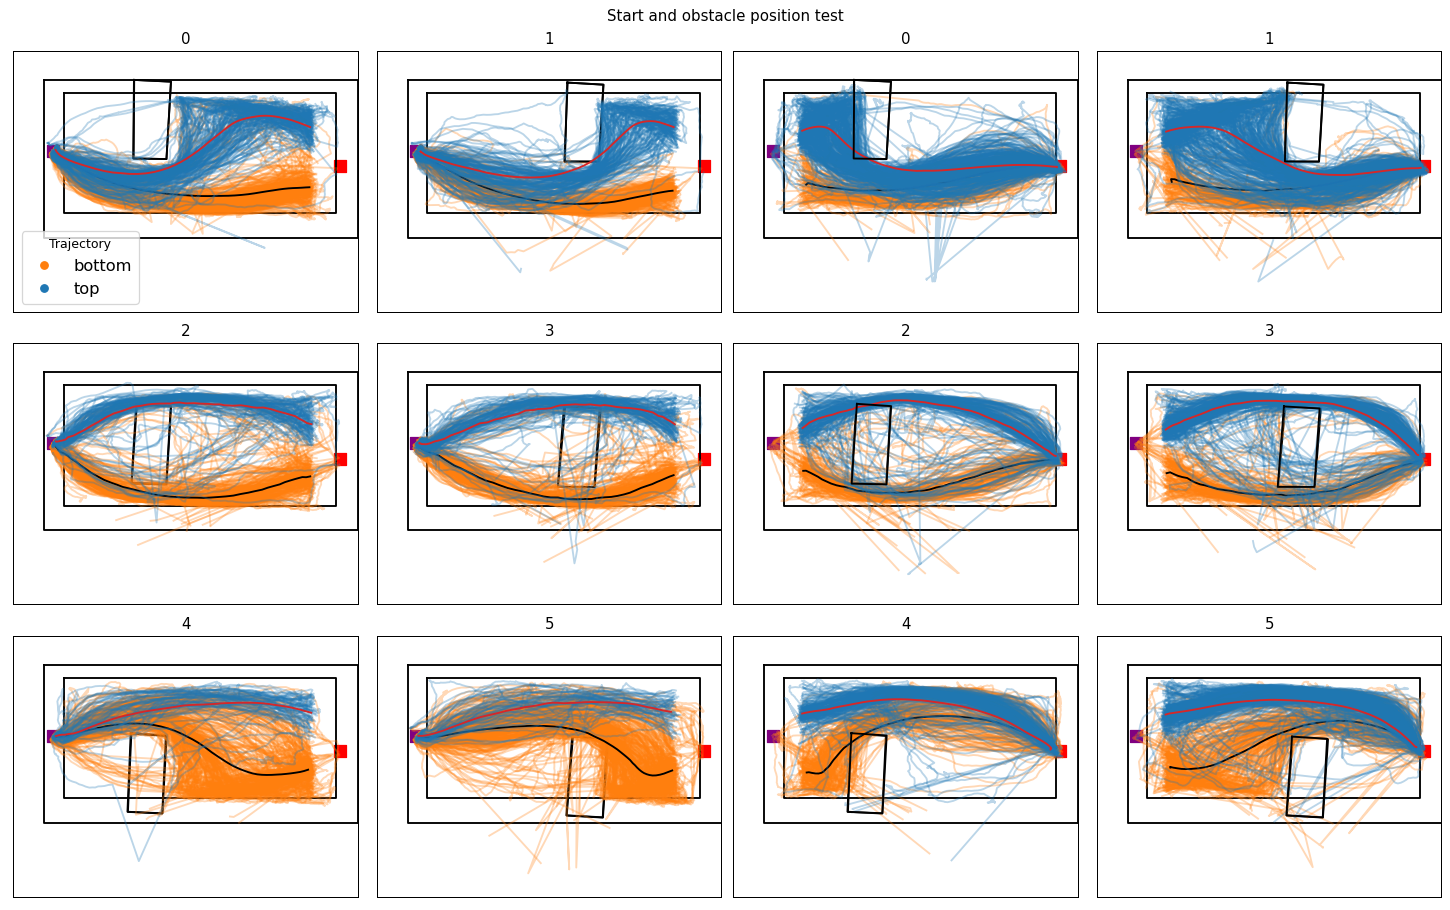

In [313]:
plot_trace(J701_df,'test')

In [312]:
def plot_trace(df,title,dark =False):
        #savepath = "D:/obstacle_avoidance/recordings"
        #savepath_session = os.path.join(*[savepath,'figures'])
        #savepath_session = os.path.join(*[savepath,str(pd.unique(df.date).item()),str(pd.unique(df.animal).item()),str(pd.unique(df.task).item())])
        #pdf = PdfPages(os.path.join((savepath_session), str(date)+ 'by_' +'_start_'+'obstacle' + 'consecutive.pdf'))
        #df = df[(df['distance_from_mean_center']<=2)]
        key='Start'
        fig = plt.figure(constrained_layout=False, figsize=(16, 10),dpi=90)
        fig.suptitle(key + ' '+ 'and ' +'obstacle position' + ' ' + title)
        spec2 = gridspec.GridSpec(ncols=2, nrows=1, figure=fig)


        """Right"""
        panel_1 = gridspec.GridSpecFromSubplotSpec(3,2,subplot_spec=spec2[0])
        ax1 = fig.add_subplot(panel_1[0,0])
        plot_arena(df,ax1)
        ax2 = fig.add_subplot(panel_1[0,1])
        plot_arena(df,ax2)
        ax2.set_title('right')
        ax3 = fig.add_subplot(panel_1[1,0])
        plot_arena(df,ax3)
        ax4 = fig.add_subplot(panel_1[1,1])
        plot_arena(df,ax4)
        ax5 = fig.add_subplot(panel_1[2,0])
        plot_arena(df,ax5)
        ax6 = fig.add_subplot(panel_1[2,1])
        plot_arena(df,ax6)

        right_axs = [ax1,ax2,ax3,ax4,ax5,ax6]
        for subplot in right_axs:
          subplot.set_xticks([])
          subplot.set_yticks([]) 
          if dark == True:
               subplot.set_facecolor('grey') 
               subplot.patch.set_alpha(.4) 
          else:
               continue
               


        """Left """
        panel_2 = gridspec.GridSpecFromSubplotSpec(3,2,subplot_spec=spec2[1])
        ax7 = fig.add_subplot(panel_2[0,0])
        plot_arena(df,ax7)
        ax8 = fig.add_subplot(panel_2[0,1])
        plot_arena(df,ax8)
        ax8.set_title('left')
        ax9 = fig.add_subplot(panel_2[1,0])
        plot_arena(df,ax9)
        ax10 = fig.add_subplot(panel_2[1,1])
        plot_arena(df,ax10)
        ax11= fig.add_subplot(panel_2[2,0])
        plot_arena(df,ax11)
        ax12 = fig.add_subplot(panel_2[2,1])
        plot_arena(df,ax12)

        left_axs = [ax7,ax8,ax9,ax10,ax11,ax12]
        for subplot in left_axs:
          subplot.set_xticks([])
          subplot.set_yticks([]) 
          if dark == True:
               subplot.set_facecolor('grey') 
               subplot.patch.set_alpha(.4) 
          else:
               continue
               






        """ plot trials"""
        right_obstacle_dict = dict(zip(pd.unique(df['obstacle_cluster'].sort_values().to_list()),right_axs))
        left_obstacle_dict = dict(zip(pd.unique(df['obstacle_cluster'].sort_values().to_list()),left_axs))

        for direction, direction_frame in df.groupby(['odd']):
          for cluster, cluster_frame in direction_frame.groupby(['obstacle_cluster']):
               
               #cluster_frame = cluster_frame.sample(num_sample)
               right_obstacle_axis = right_obstacle_dict.get(cluster)
               left_obstacle_axis = left_obstacle_dict.get(cluster)
               plot_orginal_obstacle(cluster_frame,right_obstacle_axis,cluster)
               plot_orginal_obstacle(cluster_frame,left_obstacle_axis,cluster)
               right_obstacle_axis.set_title(str(cluster))
               left_obstacle_axis.set_title(str(cluster))
               for start, start_frame in cluster_frame.groupby(['start']):
                    if direction == 'right':
                        if start == 'bottom':
                             if cluster in [2,3]:
                                  sample_df = start_frame
                                  for ind,row in sample_df.iterrows():
                                       right_obstacle_axis.plot(row.ts_nose_x_cm,row.ts_nose_y_cm,c = 'tab:orange',alpha = .3)
                                  ob_median_x = get_median_of_df(start_frame,'ts_nose_x_cm',50) 
                                  ob_median_y = get_median_of_df(start_frame,'ts_nose_y_cm',50)
                                  right_obstacle_axis.plot(ob_median_x,ob_median_y,color = 'black')
                                  
                                  
                                                                                                                   
                             else:     
                                  sample_df = start_frame
                                  for ind,row in sample_df.iterrows():
                                       right_obstacle_axis.plot(row.ts_nose_x_cm,row.ts_nose_y_cm,c = 'tab:orange',alpha = .3)
                                  ob_mean_x = get_mean_of_df(start_frame,'ts_nose_x_cm',50) 
                                  ob_mean_y = get_mean_of_df(start_frame,'ts_nose_y_cm',50)
                                  right_obstacle_axis.plot(ob_mean_x,ob_mean_y,color = 'black')
                                  
                    
                        if start == 'top':
                             if cluster in [2,3]:
                                  sample_df = start_frame
                                  for ind,row in sample_df.iterrows():
                                       right_obstacle_axis.plot(row.ts_nose_x_cm,row.ts_nose_y_cm,c = 'tab:blue',alpha =.3)
                                  ob_median_x = get_median_of_df(start_frame,'ts_nose_x_cm',50) 
                                  ob_median_y = get_median_of_df(start_frame,'ts_nose_y_cm',50)
                                  right_obstacle_axis.plot(ob_median_x,ob_median_y,color = 'tab:red')
                                  
                                  
                             else:
                                  sample_df = start_frame 
                                  for ind,row in sample_df.iterrows():
                                       right_obstacle_axis.plot(row.ts_nose_x_cm,row.ts_nose_y_cm,c = 'tab:blue',alpha =.3)    
                                  ob_mean_x = get_mean_of_df(start_frame,'ts_nose_x_cm',50) 
                                  ob_mean_y = get_mean_of_df(start_frame,'ts_nose_y_cm',50)
                                  right_obstacle_axis.plot(ob_mean_x,ob_mean_y,color = 'tab:red')
                                  
                                  
           
                              
                    if direction == 'left':
                        if start == 'bottom':
                             if cluster in [2,3]:
                                  sample_df = start_frame
                                  for ind,row in sample_df.iterrows():
                                       left_obstacle_axis.plot(row.ts_nose_x_cm,row.ts_nose_y_cm,c = 'tab:orange',alpha = .3)
                                  ob_median_x = get_median_of_df(start_frame,'ts_nose_x_cm',50) 
                                  ob_median_y = get_median_of_df(start_frame,'ts_nose_y_cm',50)
                                  left_obstacle_axis.plot(ob_median_x,ob_median_y,color = 'black')
                                  
                                  
                                                                                                                   
                             else:     
                                  sample_df = start_frame
                                  for ind,row in sample_df.iterrows():
                                       left_obstacle_axis.plot(row.ts_nose_x_cm,row.ts_nose_y_cm,c = 'tab:orange',alpha = .3)
                                  ob_mean_x = get_mean_of_df(start_frame,'ts_nose_x_cm',50) 
                                  ob_mean_y = get_mean_of_df(start_frame,'ts_nose_y_cm',50)
                                  left_obstacle_axis.plot(ob_mean_x,ob_mean_y,color = 'black')
                                  
                        
                        if start == 'top':
                             if cluster in [2,3]:
                                  sample_df = start_frame
                                  for ind,row in sample_df.iterrows():
                                       left_obstacle_axis.plot(row.ts_nose_x_cm,row.ts_nose_y_cm,c = 'tab:blue',alpha =.3)
                                  ob_median_x = get_median_of_df(start_frame,'ts_nose_x_cm',50) 
                                  ob_median_y = get_median_of_df(start_frame,'ts_nose_y_cm',50)
                                  left_obstacle_axis.plot(ob_median_x,ob_median_y,color = 'tab:red')
                                  
                                  
                             else:
                                  sample_df = start_frame 
                                  for ind,row in sample_df.iterrows():
                                       left_obstacle_axis.plot(row.ts_nose_x_cm,row.ts_nose_y_cm,c = 'tab:blue',alpha =.3)    
                                  ob_mean_x = get_mean_of_df(start_frame,'ts_nose_x_cm',50) 
                                  ob_mean_y = get_mean_of_df(start_frame,'ts_nose_y_cm',50)
                                  left_obstacle_axis.plot(ob_mean_x,ob_mean_y,color = 'tab:red')
        markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='') for color in ['tab:orange','tab:blue']]
        ax1.legend(markers, ['bottom','top'], numpoints=1,title = 'Trajectory',fontsize=13)  

Text(0.5, 1.0, 'Long')

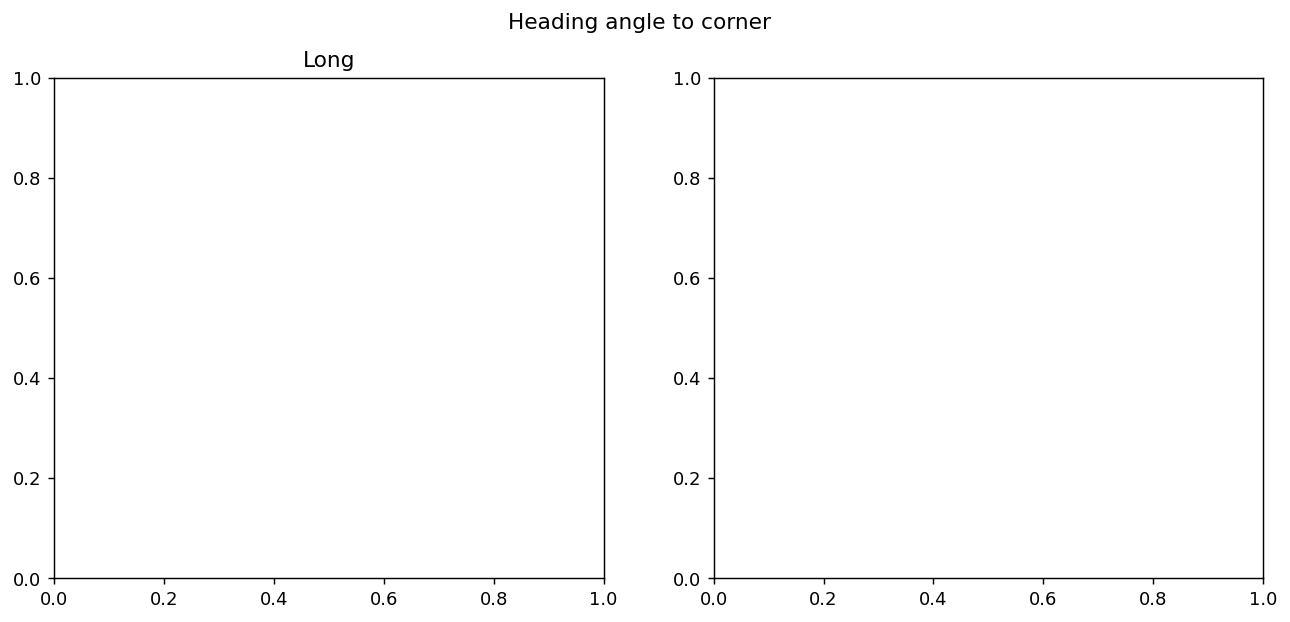

In [260]:

fig,ax = plt.subplots(1,2,dpi = 130,figsize = (12,5))
fig.suptitle('Heading angle to corner')
ax[0].set_title('Long')

In [268]:
short.ts_distance_from_edge

48     [8.32350201311213, 8.191872654096894, 7.944897...
58     [8.801111453740916, 8.702070859794587, 8.51646...
60     [8.695329325195068, 8.553116180708836, 8.28486...
5      [10.863184118655099, 10.804234407876336, 10.69...
7      [11.316077062279057, 11.291036843416947, 11.24...
11     [11.305379361293156, 11.28134757389703, 11.234...
13     [11.25114626475213, 11.223023228293016, 11.166...
15     [10.857300781014025, 10.789417329052284, 10.66...
17     [10.978738814055063, 10.933538218882752, 10.84...
25     [11.172315810809941, 11.12898770745425, 11.043...
43     [11.487684597041337, 11.401694130881197, 11.23...
65     [10.54918317198782, 10.44685913109047, 10.2507...
75     [11.274400228994509, 11.193770650184675, 11.03...
89     [11.480633678167273, 11.453055241289498, 11.39...
101    [10.736348617308515, 10.622479532937916, 10.40...
129    [11.025447829004328, 10.961404569464797, 10.84...
22     [7.469175118432453, 7.349952596704426, 7.12559...
38     [6.885978210364232, 6.77

In [267]:
long.ts_distance_from_edge

33     [23.935197561818065, 23.918602778060986, 23.88...
47     [24.321457060233122, 24.28995356179101, 24.226...
123    [23.90321866472413, 23.83826020133688, 23.7130...
6      [21.986409737800575, 21.88080711640239, 21.684...
8      [21.781732548733608, 21.70894040759965, 21.571...
34     [21.522533995633523, 21.434862754787417, 21.27...
36     [21.79510200079038, 21.70029966898754, 21.5190...
44     [21.61968440565377, 21.527404209497654, 21.351...
64     [22.05933053431073, 21.93571586932537, 21.7017...
88     [21.989429028835307, 21.884255862046626, 21.68...
100    [21.96545858227939, 21.874700413378637, 21.701...
112    [21.590674919367963, 21.454915111924105, 21.19...
114    [21.263224956901674, 21.1547022209639, 20.9541...
63     [24.13857463070073, 23.988734656200265, 23.707...
81     [23.247458057646043, 23.085514298756934, 22.78...
93     [23.183377231521114, 23.0485777847722, 22.7962...
40     [21.781598506899147, 21.68465253301993, 21.507...
42     [21.675257099331425, 21.

In [265]:
long

,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,rightear_y,...,goal_basis_end_y,obstacle_devations,goal_devations,lateral_error,ts_lateral_error_to_target_port,tortuosity,linearity,head_angle,head_angle_velocity,time
33,54991.297139,54994.377728,"[54991.302579, 54991.319436, 54991.336256, 549...","[[6872, 6873, 6874, 6875, 6876, 6877, 6878, 68...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[649.9056396484375, 650.755859375, 651.5538940...","[273.5463562011719, 272.7667236328125, 271.890...","[651.1934204101562, 651.4616088867188, 652.012...","[293.7929382324219, 293.05804443359375, 292.13...",...,21.664415,"[nan, 96.90216879667551, 97.18803895043729, 97...","[nan, 11.640490350464626, 9.839308072516486, 8...","[-4.892796937860059, -5.00277942886521, -5.209...","[2.8562881319400795, 2.966270622945231, 3.1732...",1.334389,0.749407,"[50.156291767845346, 50.18121025528633, 50.212...","[0.026094579027726716, 0.03314864338462398, 0....",3.066667
47,55039.712064,55042.476928,"[55039.719513, 55039.736051, 55039.753011, 550...","[[9776, 9777, 9778, 9779, 9780, 9781, 9782, 97...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[650.168212890625, 651.2139282226562, 651.7936...","[273.28521728515625, 272.1754455566406, 272.34...","[650.0504760742188, 650.526123046875, 650.9566...","[291.6606750488281, 291.3827819824219, 291.738...",...,21.744264,"[nan, 86.38324652877571, 85.2554973937089, 83....","[nan, 51.08414543620948, 60.06192440212369, 69...","[-6.484911552089418, -6.568866136791925, -6.72...","[4.39044072657585, 4.474395311278357, 4.630169...",1.091441,0.916220,"[45.10739330310728, 44.934722180937186, 44.579...","[-0.18082077629889337, -0.3719159870085287, -0...",2.750000
123,55271.048729,55273.989824,"[55271.049113, 55271.065868, 55271.083468, 552...","[[23651, 23652, 23653, 23654, 23655, 23656, 23...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[646.1346435546875, 647.1539306640625, 647.943...","[276.5846862792969, 276.6943054199219, 276.855...","[650.2487182617188, 650.989013671875, 650.9236...","[296.1140441894531, 296.22393798828125, 296.28...",...,22.090824,"[nan, 39.576046558601575, 39.074798783702754, ...","[nan, 1.384729683099845, 1.3835192142971162, 1...","[-3.878055775478117, -3.9629376180943794, -4.1...","[1.9831976446300494, 2.0680794872463117, 2.227...",1.052453,0.950161,"[46.929565084354884, 46.75284908376493, 46.412...","[-0.1850565630750567, -0.35619873782006817, -0...",2.933333
6,54901.030297,54904.581644,"[54901.038297, 54901.054937, 54901.072345, 549...","[1458, 1459, 1460, 1461, 1462, 1463, 1464, 146...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[73.80955505371094, 73.48487854003906, 73.8060...","[271.5731506347656, 271.76324462890625, 272.24...","[80.69176483154297, 80.84627532958984, 80.8314...","[251.56353759765625, 252.11033630371094, 252.7...",...,24.249838,"[nan, 36.17935079435097, 36.30135218739355, 36...","[nan, 24.346650376264833, 22.534456861273803, ...","[-8.37715459981018, -8.396954051782343, -8.434...","[8.752326952923415, 8.772126404895578, 8.80963...",1.181370,0.846475,"[59.466161257043055, 58.32805217977392, 56.183...","[-1.191825038710852, -2.2454497336960366, -3.0...",3.533333
8,54907.526950,54911.328409,"[54907.540377, 54907.557171, 54907.5744, 54907...","[1848, 1849, 1850, 1851, 1852, 1853, 1854, 185...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[73.7158203125, 72.8050537109375, 72.790313720...","[270.97088623046875, 271.13671875, 270.6330566...","[81.20374298095703, 80.63900756835938, 80.5448...","[250.6979217529297, 250.9718780517578, 250.875...",...,23.885619,"[nan, 3.755165031826939, 3.106730622535493, 2....","[nan, 10.139284034017743, 

In [ ]:
  for i,row in enumerate(date_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            #x = resample(x,20)
            #y = resample(np.flip(np.unique(y)),len(x))
            #y = resample(y,len(x))
            interpolater = interp1d(x,y,bounds_error=False)
            #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['ts_zero_out_angle_to_corner'])
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    date_angle_mean = np.nanmean(angle_array,axis = 0)
    date_angle_median= np.nanmedian(angle_array,axis = 0)

        

In [ ]:
def plot_angle_to_corner(df):
    """ plot zero_out_head_angle over obstacle distance"""
    xnew_short =  np.arange(-2, 10, 1)
    xnew_long =  np.arange(-2, 20, 1)
    long,short,middle = create_df_by_type(df)
    fig,ax = plt.subplots(1,2,dpi = 130,figsize = (12,5))
    fig.suptitle('Heading angle to corner')
    ax[0].set_title('Long Approach')
    ax[1].set_title('Short Approach')

    for dataframe in [long,short]:
        for task, task_df in dataframe.groupby(['task']):
            for ind,row in task_df.iterrows():
                x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
                y = row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)
                interpolater = interp1d(x,y,bounds_error=False)





            head_angle_mean,head_angle_array = get_mean_of_df(task_df,'ts_zero_out_angle_to_corner',matx=True,bins=50)
            head_angle_median= get_median_of_df(task_df,'ts_zero_out_angle_to_corner',50)



            median, q1, q3, iqr = calculate_quartiles(head_angle_array)

            if (task == 'oa') & (dataframe == 'long'):
                ax[0].fill_between(xnew, q1, q3, color='tab:orange', alpha=0.3, label='IQR')
                ax[0].plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
                ax[0].plot(xnew,date_angle_median,'--',c = 'tab:orange',alpha = 1)
            else:
                ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
                ax.plot(xnew,date_angle_mean,c = 'tab:blue',alpha = 1)
                ax.plot(xnew,date_angle_median,'--',c = 'tab:blue',alpha = 1)

        ax.set_ylabel('degrees per sec^-1')
        ax.set_xlabel('distance to obstalce (cm)')

        markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:orange','tab:blue']]
        ax.legend(markers, ['Light','Dark'], numpoints=1,loc = 'lower left',fontsize=12)
            


            


    
    

In [ ]:

xnew =  np.arange(0, 50, 1)

fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Head Turn')
#ax.invert_xaxis()
#ax.set_ylim(-1,1)
data = pd.concat([oa_long,dark_long])
data = drop_nans_in_columns(data,'obstacle_devations')
data = drop_nans_in_columns(data,'lateral_error')
data = drop_nans_in_columns(data,'speed')

data = data[(data.head_velocity_at_turn <4)]
for date ,date_df in  data.groupby(['task']):
  
   
   #rows = date_df.shape[0]
   #angle_array = np.empty([rows,len(xnew)])
   #angle_array[:] =np.nan 
   #for i,row in enumerate(date_df.iterrows()):
   #    x = row[1]['ts_distance_from_edge_at_turn']
   #    y =row[1]['head_velocity_at_turn_trace']
   #    if sum(y) == 0:
   #        continue
   #    else:
   #        #x = resample(x,20)
   #        #y = resample(np.flip(np.unique(y)),len(x))
   #        #y = resample(y,len(x))
   #        interpolater = interp1d(x,y,bounds_error=False)
   #        #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['ts_zero_out_angle_to_corner'])
   #        ynew = interpolater(xnew)
   #        angle_array[i] = ynew

    date_angle_mean,angle_array = get_mean_of_df(date_df,'head_velocity_at_turn_trace',matx=True,bins=50)
    date_angle_median= get_median_of_df(date_df,'head_velocity_at_turn_trace',50)

        

    median, q1, q3, iqr = calculate_quartiles(angle_array)
 
    if date == 'oa':
        light_array = angle_array
        ax.fill_between(xnew, q1, q3, color='tab:orange', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:orange',alpha = 1)
    else:
        ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:blue',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:blue',alpha = 1)
        
ax.set_ylabel('degrees per sec^-1')
ax.set_xlabel('distance to obstalce (cm)')
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:orange','tab:blue']]
ax.legend(markers, ['Light','Dark'], numpoints=1,loc = 'lower left',fontsize=12)